# Measuring arc spectra

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import corner
import lmfit
from lmfit import minimize, Parameters
from astropy.io import fits

import uncertainties.umath as uum
from uncertainties import ufloat
from uncertainties import unumpy as upy

import os
import sys
magePath = '/home/benjamin/Documents/analogs/'
os.sys.path.append(magePath)

from magE.directMethod import directT, run_all
from magE.functions import mergeSpec, gaussian, to_vel, FWHM, dV, save_catalog
from magE.plotutils import * 
from magE.constutils import *

PATH = '/home/benjamin/Documents/analogs/specs/final_spec/'
os.chdir(PATH)
os.getcwd()

'/home/benjamin/Documents/analogs/specs/final_spec'

In [2]:
# For intrinsic broadening
# J0023 merged specs in 5464

wcal_red = fits.open('/home/benjamin/Documents/pypeit23/redux_J0023/red/magellan_mage_A/Calibrations/WaveCalib_A_0_DET01.fits')
wcal_blue = fits.open('/home/benjamin/Documents/pypeit23/redux_J0023/blue/magellan_mage_A/Calibrations/WaveCalib_A_0_DET01.fits')

----

In [25]:
wcal_red.info()

Filename: /home/benjamin/Documents/pypeit23/redux_J0023/red/magellan_mage_A/Calibrations/WaveCalib_A_0_DET01.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      13   ()      
  1  SPAT_IDS      1 ImageHDU        26   (10,)   int64   
  2  SPAT_ID-492_WAVEFIT    1 BinTableHDU     40   1R x 6C   [91D, 91D, 91J, 2048D, 2048D, 108D]   
  3  SPAT_ID-492_PYPEITFIT    1 BinTableHDU     36   1R x 6C   [91D, 91D, 1K, 91D, 5D, 91K]   
  4  SPAT_ID-563_WAVEFIT    1 BinTableHDU     40   1R x 6C   [105D, 105D, 105J, 2048D, 2048D, 118D]   
  5  SPAT_ID-563_PYPEITFIT    1 BinTableHDU     36   1R x 6C   [105D, 105D, 1K, 105D, 5D, 105K]   
  6  SPAT_ID-629_WAVEFIT    1 BinTableHDU     40   1R x 6C   [99D, 99D, 99J, 2048D, 2048D, 111D]   
  7  SPAT_ID-629_PYPEITFIT    1 BinTableHDU     36   1R x 6C   [99D, 99D, 1K, 99D, 5D, 99K]   
  8  SPAT_ID-690_WAVEFIT    1 BinTableHDU     40   1R x 6C   [103D, 103D, 103J, 2048D, 2048D, 132D]   
  9  SPAT_ID-690_PY

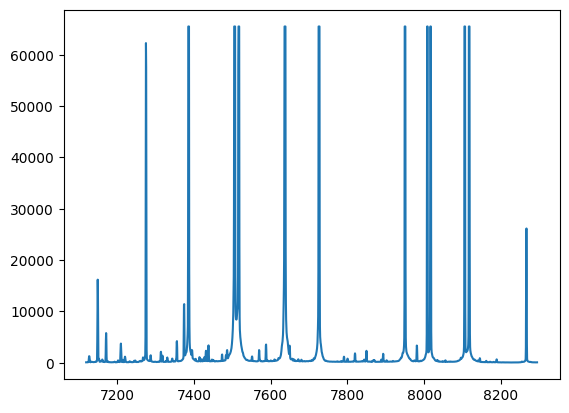

In [31]:
plt.plot(wcal_red[16].data['wave_soln'][0], wcal_red[23].data[:, 7])
#plt.xlim(6900, 6930)
#plt.ylim(0, 3500)

# [OIII]4959

### Arc lines

In [7]:
# Select a region of the arc spectra to have a few arc lines around the wavelength of the fitted lines
wlims_4959 = [wave_cat['[OIII]4959']*(1 + z_BN[igal]) - 10, wave_cat['[OIII]4959']*(1 + z_BN[igal]) + 10]
mask_arc_4959 = (wcal_blue[12].data['wave_soln'][0] >= wlims_4959[0]) & (wcal_blue[12].data['wave_soln'][0] < wlims_4959[1])

# Arc spectra around the fitted line
x_arc_4959 = wcal_blue[12].data['wave_soln'][0][mask_arc_4959]
y_arc_4959 = wcal_blue[25].data[:, 5][mask_arc_4959]

100%|███████████████████████████████████████| 2500/2500 [00:29<00:00, 84.94it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 5 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [ 21.21767821 136.31003216  81.2091791   83.48976677  37.17272632
  76.33431074  72.02435668]


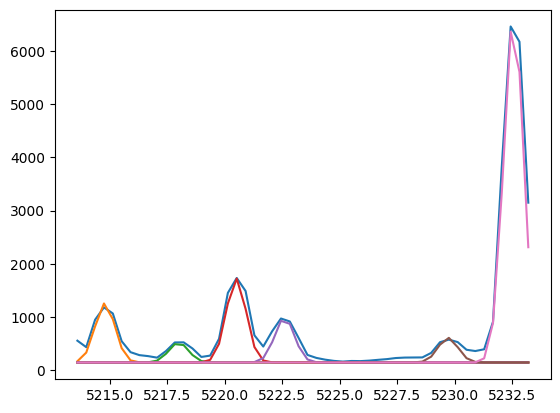

In [8]:
plt.plot(x_arc_4959, y_arc_4959)
plt.plot(x_arc_4959, 150 + gaussian(x_arc_4959, 1200, 5214.8, 0, 0.43))
plt.plot(x_arc_4959, 150 + gaussian(x_arc_4959, 400,    5218, 0, 0.43))
plt.plot(x_arc_4959, 150 + gaussian(x_arc_4959, 1700, 5220.5, 0, 0.43))
plt.plot(x_arc_4959, 150 + gaussian(x_arc_4959, 900, 5222.6, 0, 0.43))
plt.plot(x_arc_4959, 150 + gaussian(x_arc_4959, 500, 5229.7, 0, 0.43))
plt.plot(x_arc_4959, 150 + gaussian(x_arc_4959, 7000, 5232.55, 0, 0.43))

params_arc_4959 = Parameters()
params_arc_4959.add('z', value=0.0, vary=False)
params_arc_4959.add('mu1', value=5214.8, vary=False)
params_arc_4959.add('mu2', value=5218, vary=False)
params_arc_4959.add('mu3', value=5220.5, vary=False)
params_arc_4959.add('mu4', value=5222.6, vary=False)
params_arc_4959.add('mu5', value=5229.7, vary=False)
params_arc_4959.add('mu6', value=5232.55, vary=False)
params_arc_4959.add('arc1', value=1200, min=0.)
params_arc_4959.add('arc2', value=400, min=0.)
params_arc_4959.add('arc3', value=1700, min=0.)
params_arc_4959.add('arc4', value=900, min=0.)
params_arc_4959.add('arc5', value=500, min=0.)
params_arc_4959.add('arc6', value=7000, min=0.)
params_arc_4959.add('sigma', value=0.43, min=0.)
params_arc_4959.add('bkg', value=150, vary=False)

def residual_arc_4959(params_arc_4959, x, data, uncertainty):
    
    z = params_arc_4959['z']
    mu1 = params_arc_4959['mu1']
    mu2 = params_arc_4959['mu2']
    mu3 = params_arc_4959['mu3']
    mu4 = params_arc_4959['mu4']
    mu5 = params_arc_4959['mu5']
    mu6 = params_arc_4959['mu6']
    flux1 = params_arc_4959['arc1']
    flux2 = params_arc_4959['arc2']
    flux3 = params_arc_4959['arc3']
    flux4 = params_arc_4959['arc4']
    flux5 = params_arc_4959['arc5']
    flux6 = params_arc_4959['arc6']
    sigma = params_arc_4959['sigma']
    bkg = params_arc_4959['bkg']
    
    x = x_arc_4959
    model1 = gaussian(x, flux1, mu1, z, sigma)
    model2 = gaussian(x, flux2, mu2, z, sigma)
    model3 = gaussian(x, flux3, mu3, z, sigma)
    model4 = gaussian(x, flux4, mu4, z, sigma)
    model5 = gaussian(x, flux5, mu5, z, sigma)
    model6 = gaussian(x, flux6, mu6, z, sigma)
    model = bkg + model1 + model2 + model3 + model4 + model5 + model6
    return (model - y_arc_4959) / 10

np.random.seed(23)
out_arc_4959 = minimize(residual_arc_4959, params_arc_4959, args=(1, 1, 1),
                      method='emcee', burn=1500, steps=2500, thin=10)

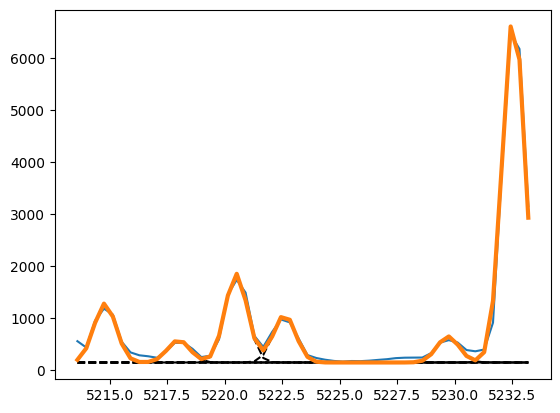

In [9]:
arc1_4959 = out_arc_4959.flatchain.arc1.mean()
arc2_4959 = out_arc_4959.flatchain.arc2.mean()
arc3_4959 = out_arc_4959.flatchain.arc3.mean()
arc4_4959 = out_arc_4959.flatchain.arc4.mean()
arc5_4959 = out_arc_4959.flatchain.arc5.mean()
arc6_4959 = out_arc_4959.flatchain.arc6.mean()
sigma_arc_4959 = out_arc_4959.flatchain.sigma.mean()

plt.plot(x_arc_4959, y_arc_4959)

plt.plot(x_arc_4959, 150 + gaussian(x_arc_4959, arc1_4959, 5214.8, 0, sigma_arc_4959), ls='--', color='black')
plt.plot(x_arc_4959, 150 + gaussian(x_arc_4959, arc2_4959, 5218, 0, sigma_arc_4959), ls='--', color='black')
plt.plot(x_arc_4959, 150 + gaussian(x_arc_4959, arc3_4959, 5220.5, 0, sigma_arc_4959), ls='--', color='black')
plt.plot(x_arc_4959, 150 + gaussian(x_arc_4959, arc4_4959, 5222.6, 0, sigma_arc_4959), ls='--', color='black')
plt.plot(x_arc_4959, 150 + gaussian(x_arc_4959, arc5_4959, 5229.7, 0, sigma_arc_4959), ls='--', color='black')
plt.plot(x_arc_4959, 150 + gaussian(x_arc_4959, arc6_4959, 5232.55, 0, sigma_arc_4959), ls='--', color='black')

plt.plot(x_arc_4959, 150 + gaussian(x_arc_4959, arc1_4959, 5214.8, 0, sigma_arc_4959) \
         + gaussian(x_arc_4959, arc2_4959, 5218, 0, sigma_arc_4959) \
         + gaussian(x_arc_4959, arc3_4959, 5220.5, 0, sigma_arc_4959) \
         + gaussian(x_arc_4959, arc4_4959, 5222.6, 0, sigma_arc_4959) \
         + gaussian(x_arc_4959, arc5_4959, 5229.7, 0, sigma_arc_4959) \
         + gaussian(x_arc_4959, arc6_4959, 5232.55, 0, sigma_arc_4959), lw=3
)

---------

# HeI 7065

### Arc lines

In [20]:
wave_cat['HeI7065']*(1 + z_BN[igal])

7442.259190299999

In [21]:
# Select a region of the arc spectra to have a few arc lines around the wavelength of the fitted lines
wlims_7065 = [wave_cat['HeI7065']*(1 + z_BN[igal]) - 10, wave_cat['HeI7065']*(1 + z_BN[igal]) + 10]
mask_arc_7065 = (wcal_red[16].data['wave_soln'][0] >= wlims_7065[0]) & (wcal_red[16].data['wave_soln'][0] < wlims_7065[1])

# Arc spectra around the fitted line
x_arc_7065 = wcal_red[16].data['wave_soln'][0][mask_arc_7065]
y_arc_7065 = wcal_red[23].data[:, 7][mask_arc_7065]

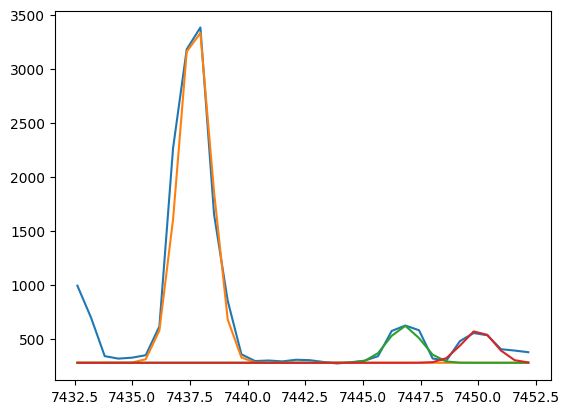

In [22]:
plt.plot(x_arc_7065, y_arc_7065)
plt.plot(x_arc_7065, 280 + gaussian(x_arc_7065, 5700, 7437.7, 0, 0.7))
plt.plot(x_arc_7065, 280 + gaussian(x_arc_7065, 600, 7446.8, 0, 0.7))
plt.plot(x_arc_7065, 280 + gaussian(x_arc_7065, 530, 7450.0, 0, 0.7))

100%|██████████████████████████████████████| 2500/2500 [00:22<00:00, 111.57it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 2 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [56.19097992 51.57473149 36.09821434 49.27706263]


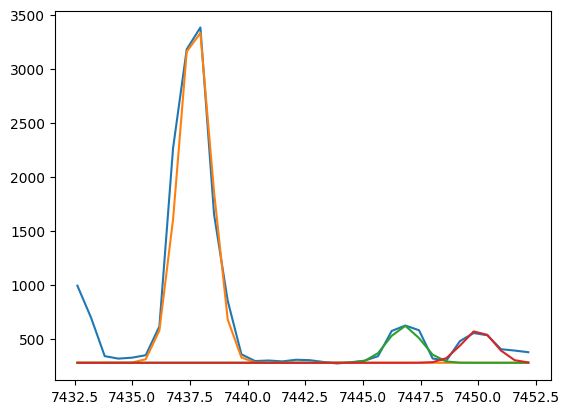

In [23]:
plt.plot(x_arc_7065, y_arc_7065)
plt.plot(x_arc_7065, 280 + gaussian(x_arc_7065, 5700, 7437.7, 0, 0.7))
plt.plot(x_arc_7065, 280 + gaussian(x_arc_7065, 600, 7446.8, 0, 0.7))
plt.plot(x_arc_7065, 280 + gaussian(x_arc_7065, 530, 7450.0, 0, 0.7))

params_arc_7065 = Parameters()
params_arc_7065.add('z', value=0.0, vary=False)
params_arc_7065.add('mu1', value=7437.7, vary=False)
params_arc_7065.add('mu2', value=7446.8, vary=False)
params_arc_7065.add('mu3', value=7450.0, vary=False)
params_arc_7065.add('arc1', value=5700, min=0.)
params_arc_7065.add('arc2', value=600, min=0.)
params_arc_7065.add('arc3', value=530, min=0.)
params_arc_7065.add('sigma', value=0.7, min=0.)
params_arc_7065.add('bkg', value=280, vary=False)

def residual_arc_7065(params_arc_7065, x, data, uncertainty):
    
    z = params_arc_7065['z']
    mu1 = params_arc_7065['mu1']
    mu2 = params_arc_7065['mu2']
    mu3 = params_arc_7065['mu3']
    flux1 = params_arc_7065['arc1']
    flux2 = params_arc_7065['arc2']
    flux3 = params_arc_7065['arc3']
    sigma = params_arc_7065['sigma']
    bkg = params_arc_7065['bkg']
    
    x = x_arc_7065
    model1 = gaussian(x, flux1, mu1, z, sigma)
    model2 = gaussian(x, flux2, mu2, z, sigma)
    model3 = gaussian(x, flux3, mu3, z, sigma)
    model = bkg + model1 + model2 + model3
    return (model - y_arc_7065) / 10

np.random.seed(23)
out_arc_7065 = minimize(residual_arc_7065, params_arc_7065, args=(1, 1, 1),
                      method='emcee', burn=1500, steps=2500, thin=10)

In [24]:
out_arc_7065.params

name,value,standard error,relative error,initial value,min,max,vary
z,0.00000000,,,0.0,-inf,inf,False
mu1,7437.70000,,,7437.7,-inf,inf,False
mu2,7446.80000,,,7446.8,-inf,inf,False
mu3,7450.00000,,,7450.0,-inf,inf,False
arc1,6205.81928,15.2500521,(0.25%),5700,0.00000000,inf,True
arc2,680.490392,12.8446617,(1.89%),600,0.00000000,inf,True
arc3,563.667519,12.3553311,(2.19%),530,0.00000000,inf,True
sigma,0.76618841,0.00218802,(0.29%),0.7,0.00000000,inf,True
bkg,280.000000,,,280,-inf,inf,False


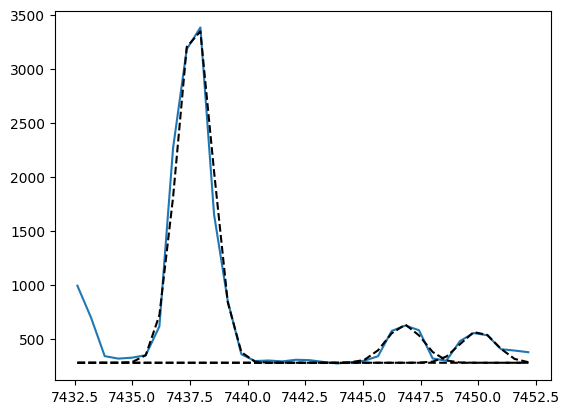

In [25]:
arc1_7065 = out_arc_7065.flatchain.arc1.mean()
arc2_7065 = out_arc_7065.flatchain.arc2.mean()
arc3_7065 = out_arc_7065.flatchain.arc3.mean()
sigma_arc_7065 = out_arc_7065.flatchain.sigma.mean()

plt.plot(x_arc_7065, y_arc_7065)

plt.plot(x_arc_7065, 280 + gaussian(x_arc_7065, arc1_7065, 7437.7, 0, sigma_arc_7065), ls='--', color='black')
plt.plot(x_arc_7065, 280 + gaussian(x_arc_7065, arc2_7065, 7446.8, 0, sigma_arc_7065), ls='--', color='black')
plt.plot(x_arc_7065, 280 + gaussian(x_arc_7065, arc3_7065, 7450.0, 0, sigma_arc_7065), ls='--', color='black')

#plt.plot(x_arc_7065, 280 + gaussian(x_arc_7065, arc1_7065, 7437.7, 0, sigma_arc_7065) \
#         + gaussian(x_arc_7065, arc2_7065, 7446.8, 0, sigma_arc_7065),
#         + gaussian(x_arc_7065, arc3_7065, 7450.0, 0, sigma_arc_7065), lw=3
#)

# HeI 6678

### Arc lines

In [34]:
wave_cat['HeI6678']*(1 + z_BN[igal])

7034.56391887

In [35]:
# Select a region of the arc spectra to have a few arc lines around the wavelength of the fitted lines
wlims_6678 = [wave_cat['HeI6678']*(1 + z_BN[igal]) - 10, wave_cat['HeI6678']*(1 + z_BN[igal]) + 10]
mask_arc_6678 = (wcal_red[14].data['wave_soln'][0] >= wlims_6678[0]) & (wcal_red[14].data['wave_soln'][0] < wlims_6678[1])

# Arc spectra around the fitted line
x_arc_6678 = wcal_red[14].data['wave_soln'][0][mask_arc_6678]
y_arc_6678 = wcal_red[23].data[:, 6][mask_arc_6678]

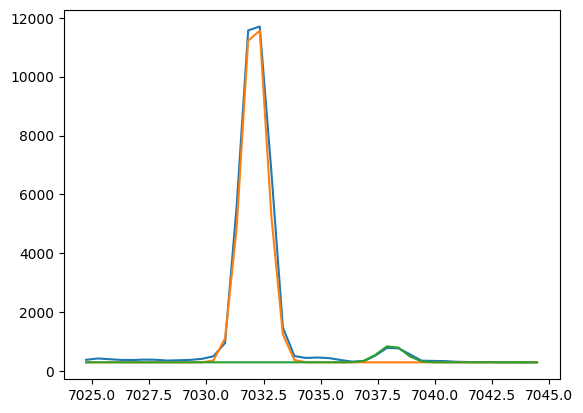

In [36]:
plt.plot(x_arc_6678, y_arc_6678)
plt.plot(x_arc_6678, 300 + gaussian(x_arc_6678, 17000, 7032.1, 0, 0.55))
plt.plot(x_arc_6678, 300 + gaussian(x_arc_6678, 800, 7038.1, 0, 0.55))

100%|██████████████████████████████████████| 2500/2500 [00:21<00:00, 118.04it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 2 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [54.86201765 31.14508729 60.02173839]


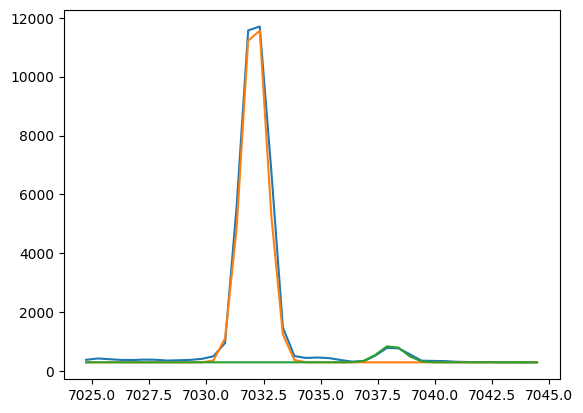

In [37]:
plt.plot(x_arc_6678, y_arc_6678)
plt.plot(x_arc_6678, 300 + gaussian(x_arc_6678, 17000, 7032.1, 0, 0.55))
plt.plot(x_arc_6678, 300 + gaussian(x_arc_6678, 800, 7038.1, 0, 0.55))

params_arc_6678 = Parameters()
params_arc_6678.add('z', value=0.0, vary=False)
params_arc_6678.add('mu1', value=7032.1, vary=False)
params_arc_6678.add('mu2', value=7038.1, vary=False)
params_arc_6678.add('arc1', value=17000, min=0.)
params_arc_6678.add('arc2', value=800, min=0.)
params_arc_6678.add('sigma', value=0.55, min=0.)
params_arc_6678.add('bkg', value=300, vary=False)

def residual_arc_6678(params_arc_6678, x, data, uncertainty):
    
    z = params_arc_6678['z']
    mu1 = params_arc_6678['mu1']
    mu2 = params_arc_6678['mu2']
    flux1 = params_arc_6678['arc1']
    flux2 = params_arc_6678['arc2']
    sigma = params_arc_6678['sigma']
    bkg = params_arc_6678['bkg']
    
    x = x_arc_6678
    model1 = gaussian(x, flux1, mu1, z, sigma)
    model2 = gaussian(x, flux2, mu2, z, sigma)
    model = bkg + model1 + model2
    return (model - y_arc_6678) / 10

np.random.seed(23)
out_arc_6678 = minimize(residual_arc_6678, params_arc_6678, args=(1, 1, 1),
                      method='emcee', burn=1500, steps=2500, thin=10)

In [38]:
out_arc_6678.params

name,value,standard error,relative error,initial value,min,max,vary
z,0.00000000,,,0.0,-inf,inf,False
mu1,7032.10000,,,7032.1,-inf,inf,False
mu2,7038.10000,,,7038.1,-inf,inf,False
arc1,18765.7713,12.2731029,(0.07%),17000,0.00000000,inf,True
arc2,794.867192,10.4748309,(1.32%),800,0.00000000,inf,True
sigma,0.59843196,4.4622e-04,(0.07%),0.55,0.00000000,inf,True
bkg,300.000000,,,300,-inf,inf,False


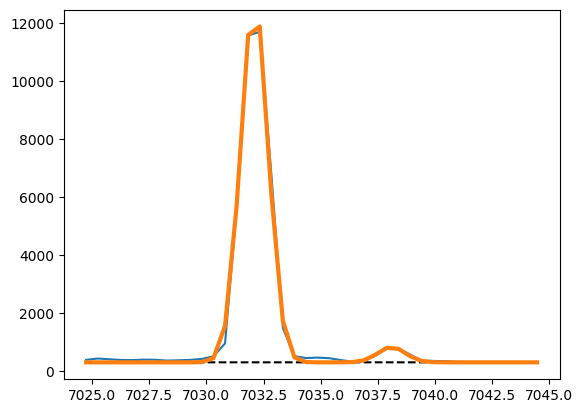

In [39]:
arc1_6678 = out_arc_6678.flatchain.arc1.mean()
arc2_6678 = out_arc_6678.flatchain.arc2.mean()
sigma_arc_6678 = out_arc_6678.flatchain.sigma.mean()

plt.plot(x_arc_6678, y_arc_6678)

plt.plot(x_arc_6678, 300 + gaussian(x_arc_6678, arc1_6678, 7032.1, 0, sigma_arc_6678), ls='--', color='black')
plt.plot(x_arc_6678, 300 + gaussian(x_arc_6678, arc2_6678, 7038.1, 0, sigma_arc_6678), ls='--', color='black')

plt.plot(x_arc_6678, 300 + gaussian(x_arc_6678, arc1_6678, 7032.1, 0, sigma_arc_6678) \
                         + gaussian(x_arc_6678, arc2_6678, 7038.1, 0, sigma_arc_6678), lw=3
)

# HeI 5875

### Arc lines

In [48]:
wave_cat['HeI5875']*(1 + z_BN[igal])

6189.202892769999

In [49]:
# Select a region of the arc spectra to have a few arc lines around the wavelength of the fitted lines
wlims_5875 = [wave_cat['HeI5875']*(1 + z_BN[igal]) - 10, wave_cat['HeI5875']*(1 + z_BN[igal]) + 10]
mask_arc_5875 = (wcal_red[12].data['wave_soln'][0] >= wlims_5875[0]) & (wcal_red[12].data['wave_soln'][0] < wlims_5875[1])

# Arc spectra around the fitted line
x_arc_5875 = wcal_red[12].data['wave_soln'][0][mask_arc_5875]
y_arc_5875 = wcal_red[23].data[:, 5][mask_arc_5875]

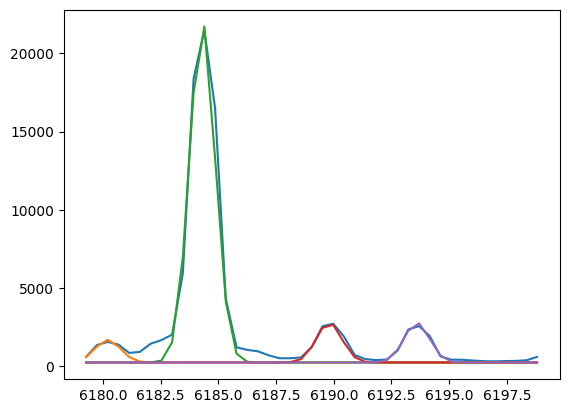

In [50]:
plt.plot(x_arc_5875, y_arc_5875)
plt.plot(x_arc_5875, 240 + gaussian(x_arc_5875, 2000, 6180.2, 0, 0.55))
plt.plot(x_arc_5875, 240 + gaussian(x_arc_5875, 30000, 6184.3, 0, 0.55))
plt.plot(x_arc_5875, 240 + gaussian(x_arc_5875, 3500, 6189.8, 0, 0.55))
plt.plot(x_arc_5875, 240 + gaussian(x_arc_5875, 3500, 6193.6, 0, 0.55))

100%|███████████████████████████████████████| 2500/2500 [00:35<00:00, 69.84it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 4 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [42.15448472 54.2866179  91.71484899 50.15040948 53.59772332]


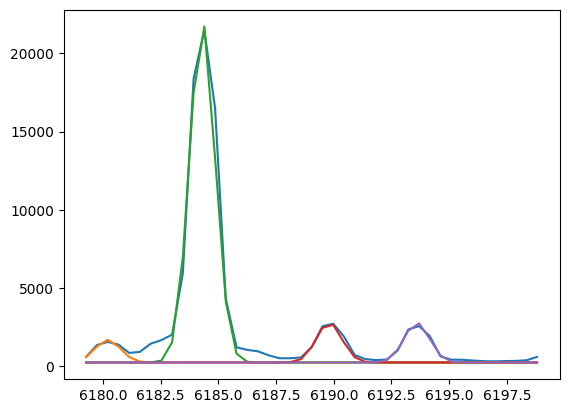

In [51]:
plt.plot(x_arc_5875, y_arc_5875)
plt.plot(x_arc_5875, 240 + gaussian(x_arc_5875, 2000, 6180.2, 0, 0.55))
plt.plot(x_arc_5875, 240 + gaussian(x_arc_5875, 30000, 6184.3, 0, 0.55))
plt.plot(x_arc_5875, 240 + gaussian(x_arc_5875, 3500, 6189.8, 0, 0.55))
plt.plot(x_arc_5875, 240 + gaussian(x_arc_5875, 3500, 6193.6, 0, 0.55))

params_arc_5875 = Parameters()
params_arc_5875.add('z', value=0.0, vary=False)
params_arc_5875.add('mu1', value=6180.2, vary=False)
params_arc_5875.add('mu2', value=6184.3, vary=False)
params_arc_5875.add('mu3', value=6189.8, vary=False)
params_arc_5875.add('mu4', value=6193.6, vary=False)
params_arc_5875.add('arc1', value=2000, min=0.)
params_arc_5875.add('arc2', value=30000, min=0.)
params_arc_5875.add('arc3', value=3500, min=0.)
params_arc_5875.add('arc4', value=3500, min=0.)
params_arc_5875.add('sigma', value=0.55, min=0.)
params_arc_5875.add('bkg', value=240, vary=False)

def residual_arc_5875(params_arc_5875, x, data, uncertainty):
    
    z = params_arc_5875['z']
    mu1 = params_arc_5875['mu1']
    mu2 = params_arc_5875['mu2']
    mu3 = params_arc_5875['mu3']
    mu4 = params_arc_5875['mu4']
    flux1 = params_arc_5875['arc1']
    flux2 = params_arc_5875['arc2']
    flux3 = params_arc_5875['arc3']
    flux4 = params_arc_5875['arc4']
    sigma = params_arc_5875['sigma']
    bkg = params_arc_5875['bkg']
    
    x = x_arc_5875
    model1 = gaussian(x, flux1, mu1, z, sigma)
    model2 = gaussian(x, flux2, mu2, z, sigma)
    model3 = gaussian(x, flux3, mu3, z, sigma)
    model4 = gaussian(x, flux4, mu4, z, sigma)
    model = bkg + model1 + model2 + model3 + model4
    return (model - y_arc_5875) / 10


np.random.seed(23)
out_arc_5875 = minimize(residual_arc_5875, params_arc_5875, args=(1, 1, 1),
                      method='emcee', burn=1500, steps=2500, thin=10)

In [52]:
out_arc_5875.params

name,value,standard error,relative error,initial value,min,max,vary
z,0.00000000,,,0.0,-inf,inf,False
mu1,6180.20000,,,6180.2,-inf,inf,False
mu2,6184.30000,,,6184.3,-inf,inf,False
mu3,6189.80000,,,6189.8,-inf,inf,False
mu4,6193.60000,,,6193.6,-inf,inf,False
arc1,2132.21834,9.91834838,(0.47%),2000,0.00000000,inf,True
arc2,32045.9724,11.7285917,(0.04%),30000,0.00000000,inf,True
arc3,3824.55039,9.63724468,(0.25%),3500,0.00000000,inf,True
arc4,3556.22477,9.77571862,(0.27%),3500,0.00000000,inf,True
sigma,0.57150107,2.3618e-04,(0.04%),0.55,0.00000000,inf,True


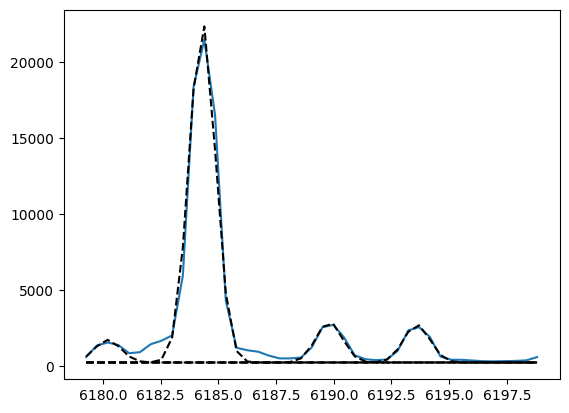

In [53]:
arc1_5875 = out_arc_5875.flatchain.arc1.mean()
arc2_5875 = out_arc_5875.flatchain.arc2.mean()
arc3_5875 = out_arc_5875.flatchain.arc3.mean()
arc4_5875 = out_arc_5875.flatchain.arc4.mean()
sigma_arc_5875 = out_arc_5875.flatchain.sigma.mean()

plt.plot(x_arc_5875, y_arc_5875)

plt.plot(x_arc_5875, 240 + gaussian(x_arc_5875, arc1_5875, 6180.2, 0, sigma_arc_5875), ls='--', color='black')
plt.plot(x_arc_5875, 240 + gaussian(x_arc_5875, arc2_5875, 6184.3, 0, sigma_arc_5875), ls='--', color='black')
plt.plot(x_arc_5875, 240 + gaussian(x_arc_5875, arc3_5875, 6189.8, 0, sigma_arc_5875), ls='--', color='black')
plt.plot(x_arc_5875, 240 + gaussian(x_arc_5875, arc4_5875, 6193.6, 0, sigma_arc_5875), ls='--', color='black')

#plt.plot(x_arc_5875, 240 + gaussian(x_arc_5875, arc1_5875, 6180.2, 0, sigma_arc_5875) \
#                         + gaussian(x_arc_5875, arc2_5875, 6184.3, 0, sigma_arc_5875),
#                         + gaussian(x_arc_5875, arc3_5875, 6189.8, 0, sigma_arc_5875),
#                         + gaussian(x_arc_5875, arc4_5875, 6193.6, 0, sigma_arc_5875), lw=3
#)

# HeI 4471

### Arc lines

In [62]:
wave_cat['HeI4471']*(1 + z_BN[igal])

4710.123098274

In [63]:
# Select a region of the arc spectra to have a few arc lines around the wavelength of the fitted lines
wlims_4471 = [wave_cat['HeI4471']*(1 + z_BN[igal]) - 10, wave_cat['HeI4471']*(1 + z_BN[igal]) + 10]
mask_arc_4471 = (wcal_blue[10].data['wave_soln'][0] >= wlims_4471[0]) & (wcal_blue[10].data['wave_soln'][0] < wlims_4471[1])

# Arc spectra around the fitted line
x_arc_4471 = wcal_blue[10].data['wave_soln'][0][mask_arc_4471]
y_arc_4471 = wcal_blue[25].data[:, 4][mask_arc_4471]

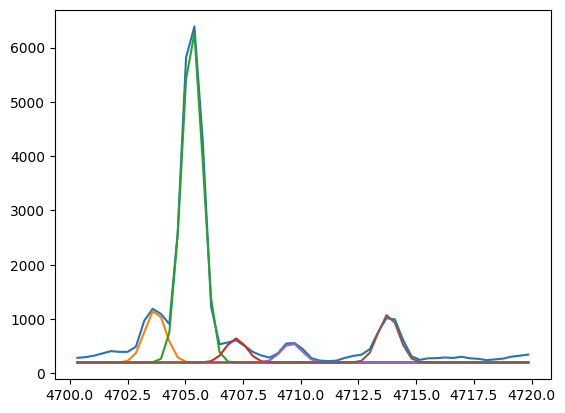

In [64]:
plt.plot(x_arc_4471, y_arc_4471)
plt.plot(x_arc_4471, 200 + gaussian(x_arc_4471, 1100, 4703.7, 0, 0.45))
plt.plot(x_arc_4471, 200 + gaussian(x_arc_4471, 7000, 4705.3, 0, 0.45))
plt.plot(x_arc_4471, 200 + gaussian(x_arc_4471, 500, 4707.2, 0, 0.45))
plt.plot(x_arc_4471, 200 + gaussian(x_arc_4471, 400, 4709.6, 0, 0.45))
plt.plot(x_arc_4471, 200 + gaussian(x_arc_4471, 1000, 4713.8, 0, 0.45))

100%|███████████████████████████████████████| 2500/2500 [00:58<00:00, 42.74it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 5 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [69.99087742 55.66340778 63.57890672 94.32913011 65.77656888 32.15101786]


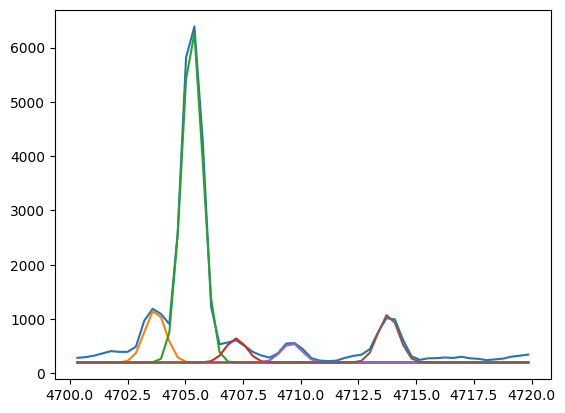

In [65]:
plt.plot(x_arc_4471, y_arc_4471)
plt.plot(x_arc_4471, 200 + gaussian(x_arc_4471, 1100, 4703.7, 0, 0.45))
plt.plot(x_arc_4471, 200 + gaussian(x_arc_4471, 7000, 4705.3, 0, 0.45))
plt.plot(x_arc_4471, 200 + gaussian(x_arc_4471, 500, 4707.2, 0, 0.45))
plt.plot(x_arc_4471, 200 + gaussian(x_arc_4471, 400, 4709.6, 0, 0.45))
plt.plot(x_arc_4471, 200 + gaussian(x_arc_4471, 1000, 4713.8, 0, 0.45))

params_arc_4471 = Parameters()
params_arc_4471.add('z', value=0.0, vary=False)
params_arc_4471.add('mu1', value=4703.7, vary=False)
params_arc_4471.add('mu2', value=4705.3, vary=False)
params_arc_4471.add('mu3', value=4707.2, vary=False)
params_arc_4471.add('mu4', value=4709.6, vary=False)
params_arc_4471.add('mu5', value=4713.8, vary=False)
params_arc_4471.add('arc1', value=1100, min=0.)
params_arc_4471.add('arc2', value=7000, min=0.)
params_arc_4471.add('arc3', value=500, min=0.)
params_arc_4471.add('arc4', value=400, min=0.)
params_arc_4471.add('arc5', value=1000, min=0.)
params_arc_4471.add('sigma', value=0.45, min=0.)
params_arc_4471.add('bkg', value=200, vary=False)

def residual_arc_4471(params_arc_4471, x, data, uncertainty):
    
    z = params_arc_4471['z']
    mu1 = params_arc_4471['mu1']
    mu2 = params_arc_4471['mu2']
    mu3 = params_arc_4471['mu3']
    mu4 = params_arc_4471['mu4']
    mu5 = params_arc_4471['mu5']
    flux1 = params_arc_4471['arc1']
    flux2 = params_arc_4471['arc2']
    flux3 = params_arc_4471['arc3']
    flux4 = params_arc_4471['arc4']
    flux5 = params_arc_4471['arc5']
    sigma = params_arc_4471['sigma']
    bkg = params_arc_4471['bkg']
    
    x = x_arc_4471
    model1 = gaussian(x, flux1, mu1, z, sigma)
    model2 = gaussian(x, flux2, mu2, z, sigma)
    model3 = gaussian(x, flux3, mu3, z, sigma)
    model4 = gaussian(x, flux4, mu4, z, sigma)
    model5 = gaussian(x, flux5, mu5, z, sigma)
    model = bkg + model1 + model2 + model3 + model4 + model5
    return (model - y_arc_4471) / 10


np.random.seed(23)
out_arc_4471 = minimize(residual_arc_4471, params_arc_4471, args=(1, 1, 1),
                      method='emcee', burn=1500, steps=2500, thin=10)

In [66]:
out_arc_4471.params

name,value,standard error,relative error,initial value,min,max,vary
z,0.00000000,,,0.0,-inf,inf,False
mu1,4703.70000,,,4703.7,-inf,inf,False
mu2,4705.30000,,,4705.3,-inf,inf,False
mu3,4707.20000,,,4707.2,-inf,inf,False
mu4,4709.60000,,,4709.6,-inf,inf,False
mu5,4713.80000,,,4713.8,-inf,inf,False
arc1,1135.66176,7.54865566,(0.66%),1100,0.00000000,inf,True
arc2,7240.31133,8.68054169,(0.12%),7000,0.00000000,inf,True
arc3,496.583184,7.72014887,(1.55%),500,0.00000000,inf,True
arc4,443.688845,7.53954503,(1.70%),400,0.00000000,inf,True


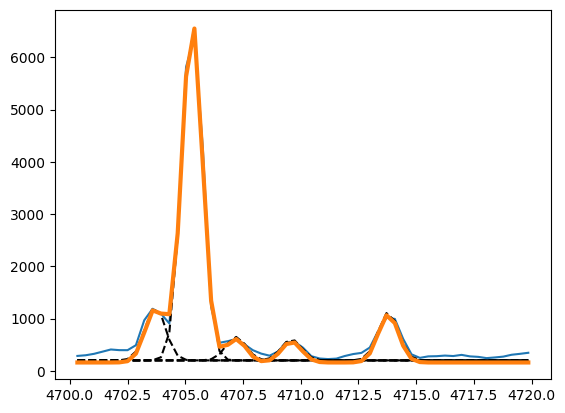

In [67]:
arc1_4471 = out_arc_4471.flatchain.arc1.mean()
arc2_4471 = out_arc_4471.flatchain.arc2.mean()
arc3_4471 = out_arc_4471.flatchain.arc3.mean()
arc4_4471 = out_arc_4471.flatchain.arc4.mean()
arc5_4471 = out_arc_4471.flatchain.arc5.mean()
sigma_arc_4471 = out_arc_4471.flatchain.sigma.mean()

plt.plot(x_arc_4471, y_arc_4471)

plt.plot(x_arc_4471, 200 + gaussian(x_arc_4471, arc1_4471, 4703.7, 0, sigma_arc_4471), ls='--', color='black')
plt.plot(x_arc_4471, 200 + gaussian(x_arc_4471, arc2_4471, 4705.3, 0, sigma_arc_4471), ls='--', color='black')
plt.plot(x_arc_4471, 200 + gaussian(x_arc_4471, arc3_4471, 4707.2, 0, sigma_arc_4471), ls='--', color='black')
plt.plot(x_arc_4471, 200 + gaussian(x_arc_4471, arc4_4471, 4709.6, 0, sigma_arc_4471), ls='--', color='black')
plt.plot(x_arc_4471, 200 + gaussian(x_arc_4471, arc5_4471, 4713.8, 0, sigma_arc_4471), ls='--', color='black')

plt.plot(x_arc_4471, 160 + gaussian(x_arc_4471, arc1_4471, 4703.7, 0, sigma_arc_4471) \
                         + gaussian(x_arc_4471, arc2_4471, 4705.3, 0, sigma_arc_4471) \
                         + gaussian(x_arc_4471, arc3_4471, 4707.2, 0, sigma_arc_4471) \
                         + gaussian(x_arc_4471, arc4_4471, 4709.6, 0, sigma_arc_4471) \
                         + gaussian(x_arc_4471, arc5_4471, 4713.8, 0, sigma_arc_4471), lw=3
)

# HeII 4686

### Arc lines

In [76]:
wave_cat['HeII4685']*(1 + z_BN[igal])

4935.786342699999

In [77]:
# Select a region of the arc spectra to have a few arc lines around the wavelength of the fitted lines
wlims_4685 = [wave_cat['HeII4685']*(1 + z_BN[igal]), wave_cat['HeII4685']*(1 + z_BN[igal]) + 10]
mask_arc_4685 = (wcal_blue[10].data['wave_soln'][0] >= wlims_4685[0]) & (wcal_blue[10].data['wave_soln'][0] < wlims_4685[1])

# Arc spectra around the fitted line
x_arc_4685 = wcal_blue[10].data['wave_soln'][0][mask_arc_4685]
y_arc_4685 = wcal_blue[25].data[:, 4][mask_arc_4685]

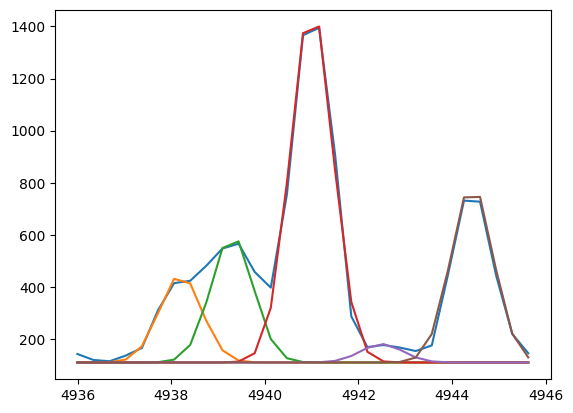

In [78]:
plt.plot(x_arc_4685, y_arc_4685)
plt.plot(x_arc_4685, 110 + gaussian(x_arc_4685, 380, 4938.2, 0, 0.45))
plt.plot(x_arc_4685, 110 + gaussian(x_arc_4685, 550, 4939.3, 0, 0.45))
plt.plot(x_arc_4685, 110 + gaussian(x_arc_4685, 1550, 4941, 0, 0.45))
plt.plot(x_arc_4685, 110 + gaussian(x_arc_4685, 80, 4942.5, 0, 0.45))
plt.plot(x_arc_4685, 110 + gaussian(x_arc_4685, 770, 4944.43, 0, 0.45))

100%|███████████████████████████████████████| 2500/2500 [01:06<00:00, 37.72it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 6 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [64.96685226 58.60604828 56.96972537 69.59278619 55.59674049 55.17451973]


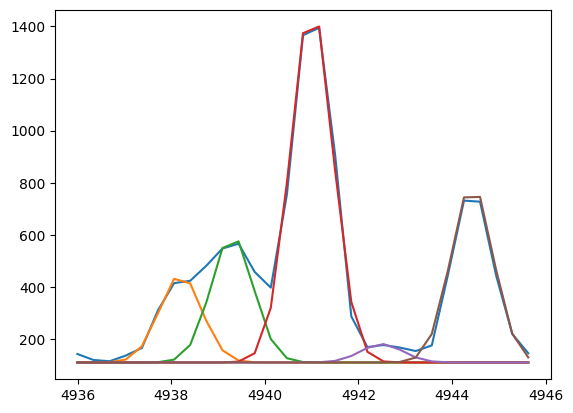

In [79]:
plt.plot(x_arc_4685, y_arc_4685)
plt.plot(x_arc_4685, 110 + gaussian(x_arc_4685, 380, 4938.2, 0, 0.45))
plt.plot(x_arc_4685, 110 + gaussian(x_arc_4685, 550, 4939.3, 0, 0.45))
plt.plot(x_arc_4685, 110 + gaussian(x_arc_4685, 1550, 4941, 0, 0.45))
plt.plot(x_arc_4685, 110 + gaussian(x_arc_4685, 80, 4942.5, 0, 0.45))
plt.plot(x_arc_4685, 110 + gaussian(x_arc_4685, 770, 4944.43, 0, 0.45))

params_arc_4685 = Parameters()
params_arc_4685.add('z', value=0.0, vary=False)
params_arc_4685.add('mu1', value=4938.2, vary=False)
params_arc_4685.add('mu2', value=4939.3, vary=False)
params_arc_4685.add('mu3', value=4941, vary=False)
params_arc_4685.add('mu4', value=4942.5, vary=False)
params_arc_4685.add('mu5', value=4944.43, vary=False)
params_arc_4685.add('arc1', value=380, min=0.)
params_arc_4685.add('arc2', value=550, min=0.)
params_arc_4685.add('arc3', value=1550, min=0.)
params_arc_4685.add('arc4', value=80, min=0.)
params_arc_4685.add('arc5', value=770, min=0.)
params_arc_4685.add('sigma', value=0.45, min=0.)
params_arc_4685.add('bkg', value=110, vary=False)

def residual_arc_4685(params_arc_4685, x, data, uncertainty):
    
    z = params_arc_4685['z']
    mu1 = params_arc_4685['mu1']
    mu2 = params_arc_4685['mu2']
    mu3 = params_arc_4685['mu3']
    mu4 = params_arc_4685['mu4']
    mu5 = params_arc_4685['mu5']
    flux1 = params_arc_4685['arc1']
    flux2 = params_arc_4685['arc2']
    flux3 = params_arc_4685['arc3']
    flux4 = params_arc_4685['arc4']
    flux5 = params_arc_4685['arc5']
    sigma = params_arc_4685['sigma']
    bkg = params_arc_4685['bkg']
    
    x = x_arc_4685
    model1 = gaussian(x, flux1, mu1, z, sigma)
    model2 = gaussian(x, flux2, mu2, z, sigma)
    model3 = gaussian(x, flux3, mu3, z, sigma)
    model4 = gaussian(x, flux4, mu4, z, sigma)
    model5 = gaussian(x, flux5, mu5, z, sigma)
    model = bkg + model1 + model2 + model3 + model4 + model5
    return (model - y_arc_4685) / 10

np.random.seed(23)
out_arc_4685 = minimize(residual_arc_4685, params_arc_4685, args=(1, 1, 1),
                      method='emcee', burn=1500, steps=2500, thin=10)

In [80]:
out_arc_4685.params

name,value,standard error,relative error,initial value,min,max,vary
z,0.00000000,,,0.0,-inf,inf,False
mu1,4938.20000,,,4938.2,-inf,inf,False
mu2,4939.30000,,,4939.3,-inf,inf,False
mu3,4941.00000,,,4941,-inf,inf,False
mu4,4942.50000,,,4942.5,-inf,inf,False
mu5,4944.43000,,,4944.43,-inf,inf,False
arc1,340.079937,7.46483007,(2.20%),380,0.00000000,inf,True
arc2,527.353039,7.44774495,(1.41%),550,0.00000000,inf,True
arc3,1523.37861,8.32958147,(0.55%),1550,0.00000000,inf,True
arc4,57.4966755,7.42526055,(12.91%),80,0.00000000,inf,True


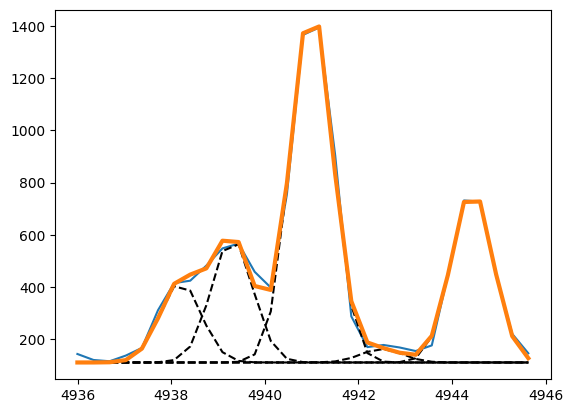

In [81]:
arc1_4685 = out_arc_4685.flatchain.arc1.mean()
arc2_4685 = out_arc_4685.flatchain.arc2.mean()
arc3_4685 = out_arc_4685.flatchain.arc3.mean()
arc4_4685 = out_arc_4685.flatchain.arc4.mean()
arc5_4685 = out_arc_4685.flatchain.arc5.mean()
sigma_arc_4685 = out_arc_4685.flatchain.sigma.mean()

plt.plot(x_arc_4685, y_arc_4685)

plt.plot(x_arc_4685, 110 + gaussian(x_arc_4685, arc1_4685, 4938.2, 0, sigma_arc_4685), ls='--', color='black')
plt.plot(x_arc_4685, 110 + gaussian(x_arc_4685, arc2_4685, 4939.3, 0, sigma_arc_4685), ls='--', color='black')
plt.plot(x_arc_4685, 110 + gaussian(x_arc_4685, arc3_4685,   4941, 0, sigma_arc_4685), ls='--', color='black')
plt.plot(x_arc_4685, 110 + gaussian(x_arc_4685, arc4_4685, 4942.5, 0, sigma_arc_4685), ls='--', color='black')
plt.plot(x_arc_4685, 110 + gaussian(x_arc_4685, arc5_4685, 4944.43, 0, sigma_arc_4685), ls='--', color='black')

plt.plot(x_arc_4685, 110 + gaussian(x_arc_4685, arc1_4685, 4938.2, 0, sigma_arc_4685) \
         + gaussian(x_arc_4685, arc2_4685, 4939.3, 0, sigma_arc_4685) \
         + gaussian(x_arc_4685, arc3_4685,   4941, 0, sigma_arc_4685) \
         + gaussian(x_arc_4685, arc4_4685, 4942.5, 0, sigma_arc_4685) \
         + gaussian(x_arc_4685, arc5_4685, 4944.43, 0, sigma_arc_4685), lw=3
)

# [NII]6548 + H$\alpha$ + [NII]6584

### Arc lines

In [91]:
wave_cat['Ha']*(1 + z_BN[igal])

6913.0461023

In [92]:
# Select a region of the arc spectra to have a few arc lines around the wavelength of the fitted lines
wlims_ha = [wave_cat['Ha']*(1 + z_BN[igal]) - 10, wave_cat['Ha']*(1 + z_BN[igal]) + 10]
mask_arc_ha = (wcal_red[14].data['wave_soln'][0] >= wlims_ha[0]) & (wcal_red[14].data['wave_soln'][0] < wlims_ha[1])

# Arc spectra around the fitted line
x_arc_ha = wcal_red[14].data['wave_soln'][0][mask_arc_ha]
y_arc_ha = wcal_red[23].data[:, 6][mask_arc_ha]

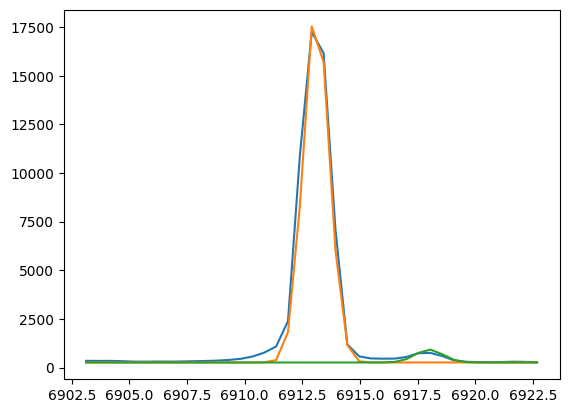

In [93]:
plt.plot(x_arc_ha, y_arc_ha)
plt.plot(x_arc_ha, 260 + gaussian(x_arc_ha, 25300, 6913.1, 0, 0.55))
plt.plot(x_arc_ha, 260 + gaussian(x_arc_ha, 1000, 6918, 0, 0.6))

100%|███████████████████████████████████████| 2500/2500 [00:53<00:00, 46.85it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 2 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [53.01946928 69.4201609  45.25020634]


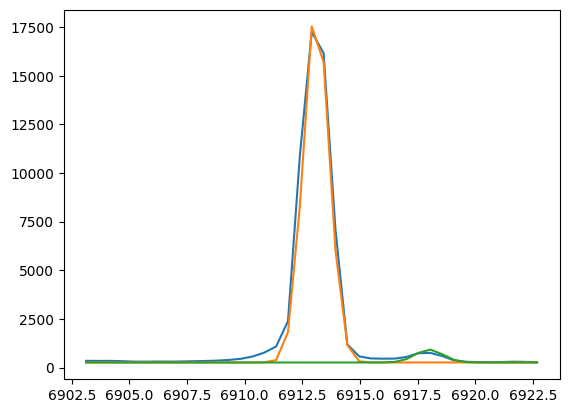

In [94]:
plt.plot(x_arc_ha, y_arc_ha)
plt.plot(x_arc_ha, 260 + gaussian(x_arc_ha, 25300, 6913.1, 0, 0.55))
plt.plot(x_arc_ha, 260 + gaussian(x_arc_ha, 1000, 6918, 0, 0.6))

params_arc_ha = Parameters()
params_arc_ha.add('z', value=0.0, vary=False)
params_arc_ha.add('mu1', value=6913.1, vary=False)
params_arc_ha.add('mu2', value=6918, vary=False)
params_arc_ha.add('arc1', value=25300, min=0.)
params_arc_ha.add('arc2', value=1000, min=0.)
params_arc_ha.add('sigma', value=0.6, min=0.)
params_arc_ha.add('bkg', value=260, vary=False)

def residual_arc_ha(params_arc_ha, x, data, uncertainty):
    
    z = params_arc_ha['z']
    mu1 = params_arc_ha['mu1']
    mu2 = params_arc_ha['mu2']
    flux1 = params_arc_ha['arc1']
    flux2 = params_arc_ha['arc2']
    sigma = params_arc_ha['sigma']
    bkg = params_arc_ha['bkg']
    
    x = x_arc_ha
    model1 = gaussian(x, flux1, mu1, z, sigma)
    model2 = gaussian(x, flux2, mu2, z, sigma)
    model = bkg + model1 + model2
    return (model - y_arc_ha) / 10

np.random.seed(23)
out_arc_ha = minimize(residual_arc_ha, params_arc_ha, args=(1, 1, 1),
                      method='emcee', burn=1500, steps=2500, thin=10)

In [95]:
out_arc_ha.params

name,value,standard error,relative error,initial value,min,max,vary
z,0.00000000,,,0.0,-inf,inf,False
mu1,6913.10000,,,6913.1,-inf,inf,False
mu2,6918.00000,,,6918,-inf,inf,False
arc1,28162.7568,12.9749883,(0.05%),25300,0.00000000,inf,True
arc2,864.370037,10.5073812,(1.22%),1000,0.00000000,inf,True
sigma,0.61714320,3.2208e-04,(0.05%),0.6,0.00000000,inf,True
bkg,260.000000,,,260,-inf,inf,False


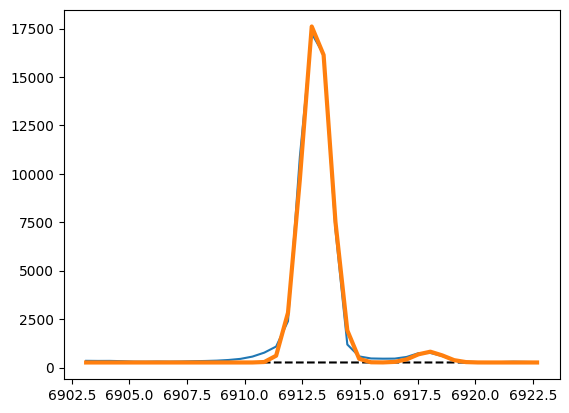

In [96]:
arc1_ha = out_arc_ha.flatchain.arc1.mean()
arc2_ha = out_arc_ha.flatchain.arc2.mean()
sigma_arc_ha = out_arc_ha.flatchain.sigma.mean()

plt.plot(x_arc_ha, y_arc_ha)

plt.plot(x_arc_ha, 260 + gaussian(x_arc_ha, arc1_ha, 6913.1, 0, sigma_arc_ha), ls='--', color='black')
plt.plot(x_arc_ha, 260 + gaussian(x_arc_ha, arc2_ha, 6918, 0, sigma_arc_ha), ls='--', color='black')

plt.plot(x_arc_ha, 260 + gaussian(x_arc_ha, arc1_ha, 6913.1, 0, sigma_arc_ha) \
                       + gaussian(x_arc_ha, arc2_ha, 6918, 0, sigma_arc_ha), lw=3
)

# [OII]7319 + [OII]7330

### Arc lines

In [105]:
# Select a region of the arc spectra to have a few arc lines around the wavelength of the fitted lines
wlims_7330 = [wave_cat['[OII]7330']*(1 + z_BN[igal]) - 60, wave_cat['[OII]7330']*(1 + z_BN[igal]) - 40]
mask_arc_7330 = (wcal_red[16].data['wave_soln'][0] >= wlims_7330[0]) & (wcal_red[16].data['wave_soln'][0] < wlims_7330[1])

# Arc spectra around the fitted line
x_arc_7330 = wcal_red[16].data['wave_soln'][0][mask_arc_7330]
y_arc_7330 = wcal_red[23].data[:, 7][mask_arc_7330]

100%|███████████████████████████████████████| 2500/2500 [02:00<00:00, 20.80it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 7 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [61.91175102 64.6823684  62.78882866 66.36168301 59.27912172 57.0697749
 62.95029825]


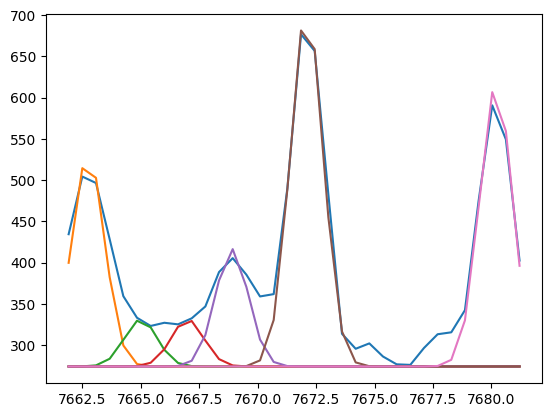

In [106]:
plt.plot(x_arc_7330, y_arc_7330)
plt.plot(x_arc_7330, 274 + gaussian(x_arc_7330, 450, 7662.75, 0, 0.7))
plt.plot(x_arc_7330, 274 + gaussian(x_arc_7330, 100, 7665, 0, 0.7))
plt.plot(x_arc_7330, 274 + gaussian(x_arc_7330, 100, 7667, 0, 0.7))
plt.plot(x_arc_7330, 274 + gaussian(x_arc_7330, 250, 7668.9, 0, 0.7))
plt.plot(x_arc_7330, 274 + gaussian(x_arc_7330, 760, 7672.1, 0, 0.7))
plt.plot(x_arc_7330, 274 + gaussian(x_arc_7330, 600, 7680.2, 0, 0.7))

params_arc_7330 = Parameters()
params_arc_7330.add('z', value=0.0, vary=False)
params_arc_7330.add('mu1', value=7662.75, vary=False)
params_arc_7330.add('mu2', value=7665, vary=False)
params_arc_7330.add('mu3', value=7667, vary=False)
params_arc_7330.add('mu4', value=7668.9, vary=False)
params_arc_7330.add('mu5', value=7672.1, vary=False)
params_arc_7330.add('mu6', value=7680.2, vary=False)
params_arc_7330.add('arc1', value=450, min=0.)
params_arc_7330.add('arc2', value=100, min=0.)
params_arc_7330.add('arc3', value=100, min=0.)
params_arc_7330.add('arc4', value=250, min=0.)
params_arc_7330.add('arc5', value=760, min=0.)
params_arc_7330.add('arc6', value=600, min=0.)
params_arc_7330.add('sigma', value=0.7, min=0.)
params_arc_7330.add('bkg', value=274, vary=False)

def residual_arc_7330(params_arc_7330, x, data, uncertainty):
    
    z = params_arc_7330['z']
    mu1 = params_arc_7330['mu1']
    mu2 = params_arc_7330['mu2']
    mu3 = params_arc_7330['mu3']
    mu4 = params_arc_7330['mu4']
    mu5 = params_arc_7330['mu5']
    mu6 = params_arc_7330['mu6']
    flux1 = params_arc_7330['arc1']
    flux2 = params_arc_7330['arc2']
    flux3 = params_arc_7330['arc3']
    flux4 = params_arc_7330['arc4']
    flux5 = params_arc_7330['arc5']
    flux6 = params_arc_7330['arc6']
    sigma = params_arc_7330['sigma']
    bkg = params_arc_7330['bkg']
    
    x = x_arc_7330
    model1 = gaussian(x, flux1, mu1, z, sigma)
    model2 = gaussian(x, flux2, mu2, z, sigma)
    model3 = gaussian(x, flux3, mu3, z, sigma)
    model4 = gaussian(x, flux4, mu4, z, sigma)
    model5 = gaussian(x, flux5, mu5, z, sigma)
    model6 = gaussian(x, flux6, mu6, z, sigma)
    model = bkg + model1 + model2 + model3 + model4 + model5 + model6
    return (model - y_arc_7330) / 10

np.random.seed(23)
out_arc_7330 = minimize(residual_arc_7330, params_arc_7330, args=(1, 1, 1),
                      method='emcee', burn=1500, steps=2500, thin=10)

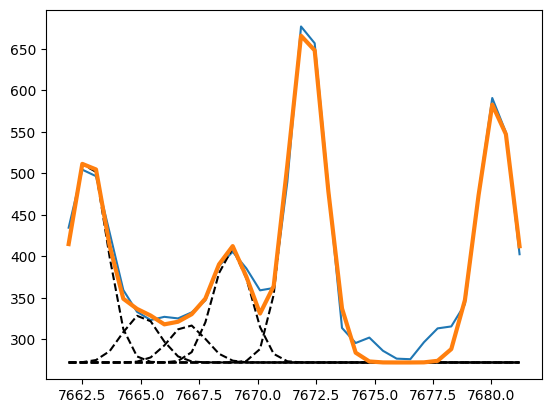

In [107]:
arc1_7330 = out_arc_7330.flatchain.arc1.mean()
arc2_7330 = out_arc_7330.flatchain.arc2.mean()
arc3_7330 = out_arc_7330.flatchain.arc3.mean()
arc4_7330 = out_arc_7330.flatchain.arc4.mean()
arc5_7330 = out_arc_7330.flatchain.arc5.mean()
arc6_7330 = out_arc_7330.flatchain.arc6.mean()
sigma_arc_7330 = out_arc_7330.flatchain.sigma.mean()

plt.plot(x_arc_7330, y_arc_7330)

plt.plot(x_arc_7330, 272 + gaussian(x_arc_7330, arc1_7330, 7662.75, 0, sigma_arc_7330), ls='--', color='black')
plt.plot(x_arc_7330, 272 + gaussian(x_arc_7330, arc2_7330, 7665, 0, sigma_arc_7330), ls='--', color='black')
plt.plot(x_arc_7330, 272 + gaussian(x_arc_7330, arc3_7330, 7667, 0, sigma_arc_7330), ls='--', color='black')
plt.plot(x_arc_7330, 272 + gaussian(x_arc_7330, arc4_7330, 7668.9, 0, sigma_arc_7330), ls='--', color='black')
plt.plot(x_arc_7330, 272 + gaussian(x_arc_7330, arc5_7330, 7672.1, 0, sigma_arc_7330), ls='--', color='black')
plt.plot(x_arc_7330, 272 + gaussian(x_arc_7330, arc6_7330, 7680.2, 0, sigma_arc_7330), ls='--', color='black')

plt.plot(x_arc_7330, 272 + gaussian(x_arc_7330, arc1_7330, 7662.75, 0, sigma_arc_7330) \
         + gaussian(x_arc_7330, arc2_7330, 7665, 0, sigma_arc_7330) \
         + gaussian(x_arc_7330, arc3_7330, 7667, 0, sigma_arc_7330) \
         + gaussian(x_arc_7330, arc4_7330, 7668.9, 0, sigma_arc_7330) \
         + gaussian(x_arc_7330, arc5_7330, 7672.1, 0, sigma_arc_7330) \
         + gaussian(x_arc_7330, arc6_7330, 7680.2, 0, sigma_arc_7330), lw=3
)

# [SII]6716 + [SII]6730

### Arc lines

In [116]:
# Select a region of the arc spectra to have a few arc lines around the wavelength of the fitted lines
wlims_6730 = [wave_cat['[SII]6730']*(1 + z_BN[igal]) - 10, wave_cat['[SII]6730']*(1 + z_BN[igal]) + 10]
mask_arc_6730 = (wcal_red[14].data['wave_soln'][0] >= wlims_6730[0]) & (wcal_red[14].data['wave_soln'][0] < wlims_6730[1])

# Arc spectra around the fitted line
x_arc_6730 = wcal_red[14].data['wave_soln'][0][mask_arc_6730]
y_arc_6730 = wcal_red[23].data[:, 6][mask_arc_6730]

100%|███████████████████████████████████████| 2500/2500 [01:17<00:00, 32.21it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 3 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [62.84194932 46.9706936  50.430409   53.59186314]


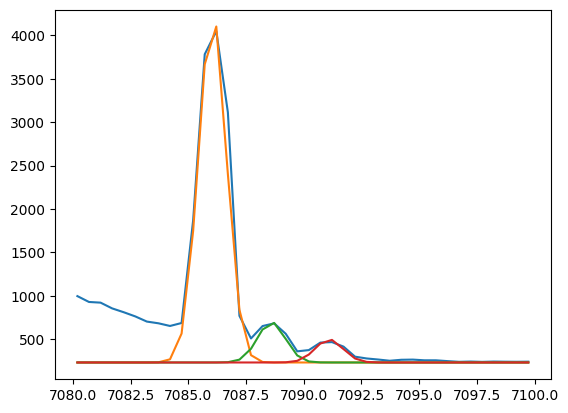

In [117]:
plt.plot(x_arc_6730, y_arc_6730)
plt.plot(x_arc_6730, 230 + gaussian(x_arc_6730, 6050, 7086.05, 0, 0.6))
plt.plot(x_arc_6730, 230 + gaussian(x_arc_6730, 700, 7088.6, 0, 0.6))
plt.plot(x_arc_6730, 230 + gaussian(x_arc_6730, 400, 7091.1, 0, 0.6))

params_arc_6730 = Parameters()
params_arc_6730.add('z', value=0.0, vary=False)
params_arc_6730.add('mu1', value=7086.05, vary=False)
params_arc_6730.add('mu2', value=7088.6, vary=False)
params_arc_6730.add('mu3', value=7091.1, vary=False)
params_arc_6730.add('arc1', value=6050, min=0.)
params_arc_6730.add('arc2', value=700, min=0.)
params_arc_6730.add('arc3', value=400, min=0.)
params_arc_6730.add('sigma', value=0.6, min=0.)
params_arc_6730.add('bkg', value=230, vary=False)

def residual_arc_6730(params_arc_6730, x, data, uncertainty):
    
    z = params_arc_6730['z']
    mu1 = params_arc_6730['mu1']
    mu2 = params_arc_6730['mu2']
    mu3 = params_arc_6730['mu3']
    flux1 = params_arc_6730['arc1']
    flux2 = params_arc_6730['arc2']
    flux3 = params_arc_6730['arc3']
    sigma = params_arc_6730['sigma']
    bkg = params_arc_6730['bkg']
    
    x = x_arc_6730
    model1 = gaussian(x, flux1, mu1, z, sigma)
    model2 = gaussian(x, flux2, mu2, z, sigma)
    model3 = gaussian(x, flux3, mu3, z, sigma)
    model = bkg + model1 + model2 + model3
    return (model - y_arc_6730) / 10

np.random.seed(23)
out_arc_6730 = minimize(residual_arc_6730, params_arc_6730, args=(1, 1, 1),
                      method='emcee', burn=1500, steps=2500, thin=10)

In [118]:
out_arc_6730.params

name,value,standard error,relative error,initial value,min,max,vary
z,0.00000000,,,0.0,-inf,inf,False
mu1,7086.05000,,,7086.05,-inf,inf,False
mu2,7088.60000,,,7088.6,-inf,inf,False
mu3,7091.10000,,,7091.1,-inf,inf,False
arc1,6645.32894,12.9974087,(0.20%),6050,0.00000000,inf,True
arc2,739.055274,10.8439140,(1.47%),700,0.00000000,inf,True
arc3,429.982934,10.5984016,(2.46%),400,0.00000000,inf,True
sigma,0.64811932,0.00138725,(0.21%),0.6,0.00000000,inf,True
bkg,230.000000,,,230,-inf,inf,False


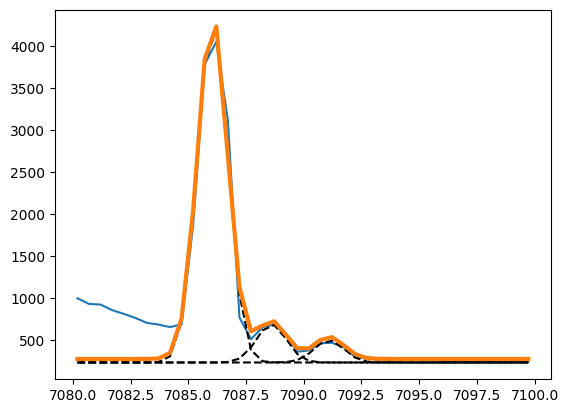

In [119]:
arc1_6730 = out_arc_6730.flatchain.arc1.mean()
arc2_6730 = out_arc_6730.flatchain.arc2.mean()
arc3_6730 = out_arc_6730.flatchain.arc3.mean()
sigma_arc_6730 = out_arc_6730.flatchain.sigma.mean()

plt.plot(x_arc_6730, y_arc_6730)

plt.plot(x_arc_6730, 230 + gaussian(x_arc_6730, arc1_6730, 7086.05, 0, sigma_arc_6730), ls='--', color='black')
plt.plot(x_arc_6730, 230 + gaussian(x_arc_6730, arc2_6730, 7088.6, 0, sigma_arc_6730), ls='--', color='black')
plt.plot(x_arc_6730, 230 + gaussian(x_arc_6730, arc3_6730, 7091.1, 0, sigma_arc_6730), ls='--', color='black')

plt.plot(x_arc_6730, 272 + gaussian(x_arc_6730, arc1_6730, 7086.05, 0, sigma_arc_6730) \
         + gaussian(x_arc_6730, arc2_6730, 7088.6, 0, sigma_arc_6730) \
         + gaussian(x_arc_6730, arc3_6730, 7091.1, 0, sigma_arc_6730), lw=3
)

# H$\beta$

### Arc lines

In [128]:
# Select a region of the arc spectra to have a few arc lines around the wavelength of the fitted lines
wlims_hb = [wave_cat['Hb']*(1 + z_BN[igal]) - 10, wave_cat['Hb']*(1 + z_BN[igal]) + 10]
mask_arc_hb = (wcal_blue[12].data['wave_soln'][0] >= wlims_hb[0]) & (wcal_blue[12].data['wave_soln'][0] < wlims_hb[1])

# Arc spectra around the fitted line
x_arc_hb = wcal_blue[12].data['wave_soln'][0][mask_arc_hb]
y_arc_hb = wcal_blue[25].data[:, 5][mask_arc_hb]

100%|███████████████████████████████████████| 2500/2500 [01:41<00:00, 24.64it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 5 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [71.93278158 46.86498128 84.630204   85.65106599 77.40950376 52.25431329]


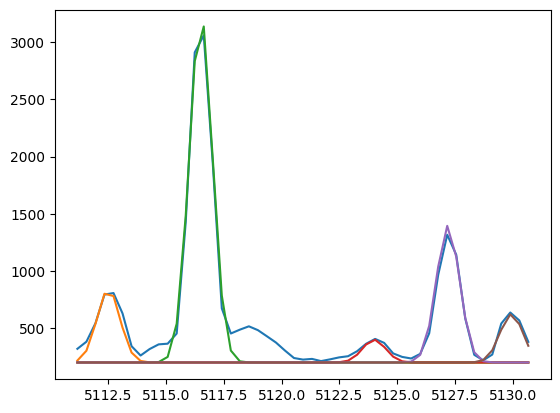

In [129]:
plt.plot(x_arc_hb, y_arc_hb)
plt.plot(x_arc_hb, 200 + gaussian(x_arc_hb, 800, 5112.5, 0, 0.5))
plt.plot(x_arc_hb, 200 + gaussian(x_arc_hb, 3800, 5116.5, 0, 0.5))
plt.plot(x_arc_hb, 200 + gaussian(x_arc_hb, 250, 5124, 0, 0.5))
plt.plot(x_arc_hb, 200 + gaussian(x_arc_hb, 1500, 5127.2, 0, 0.5))
plt.plot(x_arc_hb, 200 + gaussian(x_arc_hb, 530, 5129.95, 0, 0.5))

params_arc_hb = Parameters()
params_arc_hb.add('z', value=0.0, vary=False)
params_arc_hb.add('mu1', value=5112.5, vary=False)
params_arc_hb.add('mu2', value=5116.5, vary=False)
params_arc_hb.add('mu3', value=5124, vary=False)
params_arc_hb.add('mu4', value=5127.2, vary=False)
params_arc_hb.add('mu5', value=5129.95, vary=False)
params_arc_hb.add('arc1', value=800, min=0.)
params_arc_hb.add('arc2', value=3800, min=0.)
params_arc_hb.add('arc3', value=250, min=0.)
params_arc_hb.add('arc4', value=1500, min=0.)
params_arc_hb.add('arc5', value=530, min=0.)
params_arc_hb.add('sigma', value=0.5, min=0.)
params_arc_hb.add('bkg', value=200, vary=False)

def residual_arc_hb(params_arc_hb, x, data, uncertainty):
    
    z = params_arc_hb['z']
    mu1 = params_arc_hb['mu1']
    mu2 = params_arc_hb['mu2']
    mu3 = params_arc_hb['mu3']
    mu4 = params_arc_hb['mu4']
    mu5 = params_arc_hb['mu5']
    flux1 = params_arc_hb['arc1']
    flux2 = params_arc_hb['arc2']
    flux3 = params_arc_hb['arc3']
    flux4 = params_arc_hb['arc4']
    flux5 = params_arc_hb['arc5']
    sigma = params_arc_hb['sigma']
    bkg = params_arc_hb['bkg']
    
    x = x_arc_hb
    model1 = gaussian(x, flux1, mu1, z, sigma)
    model2 = gaussian(x, flux2, mu2, z, sigma)
    model3 = gaussian(x, flux3, mu3, z, sigma)
    model4 = gaussian(x, flux4, mu4, z, sigma)
    model5 = gaussian(x, flux5, mu5, z, sigma)
    model = bkg + model1 + model2 + model3 + model4 + model5
    return (model - y_arc_hb) / 10

np.random.seed(23)
out_arc_hb = minimize(residual_arc_hb, params_arc_hb, args=(1, 1, 1),
                      method='emcee', burn=1500, steps=2500, thin=10)

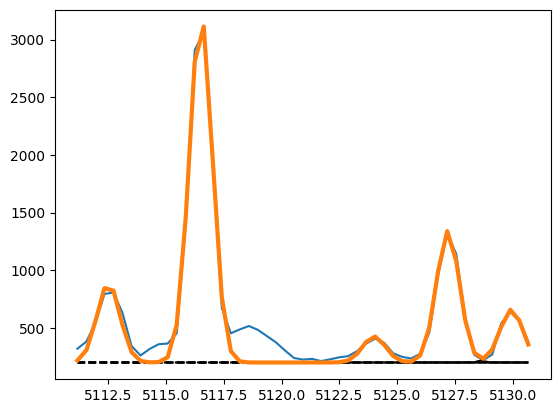

In [130]:
arc1_hb = out_arc_hb.flatchain.arc1.mean()
arc2_hb = out_arc_hb.flatchain.arc2.mean()
arc3_hb = out_arc_hb.flatchain.arc3.mean()
arc4_hb = out_arc_hb.flatchain.arc4.mean()
arc5_hb = out_arc_hb.flatchain.arc5.mean()
sigma_arc_hb = out_arc_hb.flatchain.sigma.mean()

plt.plot(x_arc_hb, y_arc_hb)

plt.plot(x_arc_hb, 200 + gaussian(x_arc_hb, arc1_hb, 5112.5, 0, sigma_arc_hb), ls='--', color='black')
plt.plot(x_arc_hb, 200 + gaussian(x_arc_hb, arc2_hb, 5116.5, 0, sigma_arc_hb), ls='--', color='black')
plt.plot(x_arc_hb, 200 + gaussian(x_arc_hb, arc3_hb, 5124, 0, sigma_arc_hb), ls='--', color='black')
plt.plot(x_arc_hb, 200 + gaussian(x_arc_hb, arc4_hb, 5127.2, 0, sigma_arc_hb), ls='--', color='black')
plt.plot(x_arc_hb, 200 + gaussian(x_arc_hb, arc5_hb, 5129.95, 0, sigma_arc_hb), ls='--', color='black')

plt.plot(x_arc_hb, 200 + gaussian(x_arc_hb, arc1_hb, 5112.5, 0, sigma_arc_hb) \
         + gaussian(x_arc_hb, arc2_hb, 5116.5, 0, sigma_arc_hb) \
         + gaussian(x_arc_hb, arc3_hb, 5124, 0, sigma_arc_hb) \
         + gaussian(x_arc_hb, arc4_hb, 5127.2, 0, sigma_arc_hb) \
         + gaussian(x_arc_hb, arc5_hb, 5129.95, 0, sigma_arc_hb), lw=3
)

# H$\gamma$

### Arc lines

In [139]:
wave_cat['Hg']*(1 + z_BN[igal])

4572.122990639999

In [140]:
# Select a region of the arc spectra to have a few arc lines around the wavelength of the fitted lines
wlims_hg = [wave_cat['Hg']*(1 + z_BN[igal]) - 10, wave_cat['Hg']*(1 + z_BN[igal]) + 10]
mask_arc_hg = (wcal_blue[10].data['wave_soln'][0] >= wlims_hg[0]) & (wcal_blue[10].data['wave_soln'][0] < wlims_hg[1])

# Arc spectra around the fitted line
x_arc_hg = wcal_blue[10].data['wave_soln'][0][mask_arc_hg]
y_arc_hg = wcal_blue[25].data[:, 4][mask_arc_hg]

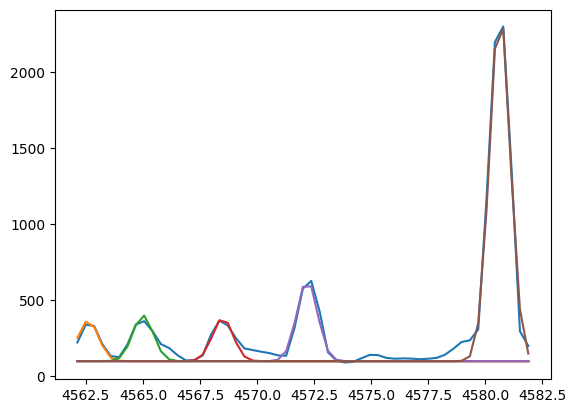

In [141]:
plt.plot(x_arc_hg, y_arc_hg)
plt.plot(x_arc_hg, 100 + gaussian(x_arc_hg,  300,  4562.6, 0, 0.45))
plt.plot(x_arc_hg, 100 + gaussian(x_arc_hg,  340,    4565, 0, 0.45))
plt.plot(x_arc_hg, 100 + gaussian(x_arc_hg,  320,  4568.5, 0, 0.45))
plt.plot(x_arc_hg, 100 + gaussian(x_arc_hg,  600,  4572.2, 0, 0.45))
plt.plot(x_arc_hg, 100 + gaussian(x_arc_hg, 2600, 4580.65, 0, 0.45))

In [142]:
params_arc_hg = Parameters()
params_arc_hg.add('z', value=0.0, vary=False)
params_arc_hg.add('mu1', value= 4562.6, vary=False)
params_arc_hg.add('mu2', value=   4565, vary=False)
params_arc_hg.add('mu3', value= 4568.5, vary=False)
params_arc_hg.add('mu4', value= 4572.2, vary=False)
params_arc_hg.add('mu5', value=4580.65, vary=False)
params_arc_hg.add('arc1', value= 300, min=0.)
params_arc_hg.add('arc2', value= 340, min=0.)
params_arc_hg.add('arc3', value= 320, min=0.)
params_arc_hg.add('arc4', value= 600, min=0.)
params_arc_hg.add('arc5', value=2600, min=0.)
params_arc_hg.add('sigma', value=0.5, min=0.)
params_arc_hg.add('bkg', value=100, vary=False)

def residual_arc_hg(params_arc_hg, x, data, uncertainty):
    
    z = params_arc_hg['z']
    mu1 = params_arc_hg['mu1']
    mu2 = params_arc_hg['mu2']
    mu3 = params_arc_hg['mu3']
    mu4 = params_arc_hg['mu4']
    mu5 = params_arc_hg['mu5']
    flux1 = params_arc_hg['arc1']
    flux2 = params_arc_hg['arc2']
    flux3 = params_arc_hg['arc3']
    flux4 = params_arc_hg['arc4']
    flux5 = params_arc_hg['arc5']
    sigma = params_arc_hg['sigma']
    bkg = params_arc_hg['bkg']
    
    x = x_arc_hg
    model1 = gaussian(x, flux1, mu1, z, sigma)
    model2 = gaussian(x, flux2, mu2, z, sigma)
    model3 = gaussian(x, flux3, mu3, z, sigma)
    model4 = gaussian(x, flux4, mu4, z, sigma)
    model5 = gaussian(x, flux5, mu5, z, sigma)
    model = bkg + model1 + model2 + model3 + model4 + model5
    return (model - y_arc_hg) / 10

np.random.seed(23)
out_arc_hg = minimize(residual_arc_hg, params_arc_hg, args=(1, 1, 1),
                      method='emcee', burn=1500, steps=2500, thin=10)

100%|███████████████████████████████████████| 2500/2500 [01:30<00:00, 27.68it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 5 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [66.16645968 47.68982959 50.56694227 53.38525508 57.11393479 50.78341218]


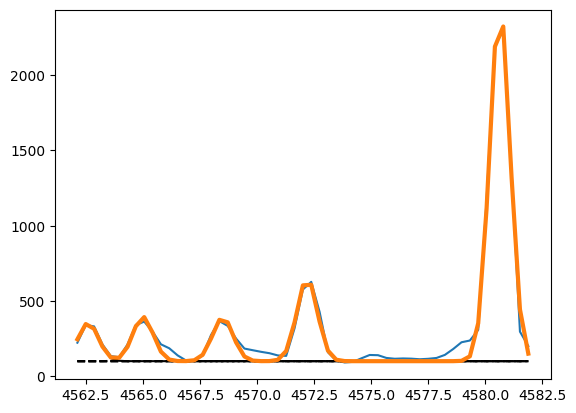

In [143]:
arc1_hg = out_arc_hg.flatchain.arc1.mean()
arc2_hg = out_arc_hg.flatchain.arc2.mean()
arc3_hg = out_arc_hg.flatchain.arc3.mean()
arc4_hg = out_arc_hg.flatchain.arc4.mean()
arc5_hg = out_arc_hg.flatchain.arc5.mean()
sigma_arc_hg = out_arc_hg.flatchain.sigma.mean()

plt.plot(x_arc_hg, y_arc_hg)

plt.plot(x_arc_hg, 100 + gaussian(x_arc_hg, arc1_hg,  4562.6, 0, sigma_arc_hg), ls='--', color='black')
plt.plot(x_arc_hg, 100 + gaussian(x_arc_hg, arc2_hg,    4565, 0, sigma_arc_hg), ls='--', color='black')
plt.plot(x_arc_hg, 100 + gaussian(x_arc_hg, arc3_hg,  4568.5, 0, sigma_arc_hg), ls='--', color='black')
plt.plot(x_arc_hg, 100 + gaussian(x_arc_hg, arc4_hg,  4572.2, 0, sigma_arc_hg), ls='--', color='black')
plt.plot(x_arc_hg, 100 + gaussian(x_arc_hg, arc5_hg, 4580.65, 0, sigma_arc_hg), ls='--', color='black')

plt.plot(x_arc_hg, 100 + gaussian(x_arc_hg, arc1_hg,  4562.6, 0, sigma_arc_hg) \
                       + gaussian(x_arc_hg, arc2_hg,    4565, 0, sigma_arc_hg) \
                       + gaussian(x_arc_hg, arc3_hg,  4568.5, 0, sigma_arc_hg) \
                       + gaussian(x_arc_hg, arc4_hg,  4572.2, 0, sigma_arc_hg) \
                       + gaussian(x_arc_hg, arc5_hg, 4580.65, 0, sigma_arc_hg), lw=3
)

# H$\delta$

### Arc lines

In [152]:
wave_cat['Hd']*(1 + z_BN[igal])

4320.61855448349

In [153]:
# Select a region of the arc spectra to have a few arc lines around the wavelength of the fitted lines
wlims_hd = [wave_cat['Hd']*(1 + z_BN[igal]) - 9, wave_cat['Hd']*(1 + z_BN[igal]) + 5]
mask_arc_hd = (wcal_blue[8].data['wave_soln'][0] >= wlims_hd[0]) & (wcal_blue[8].data['wave_soln'][0] < wlims_hd[1])

# Arc spectra around the fitted line
x_arc_hd = wcal_blue[8].data['wave_soln'][0][mask_arc_hd]
y_arc_hd = wcal_blue[25].data[:, 3][mask_arc_hd]

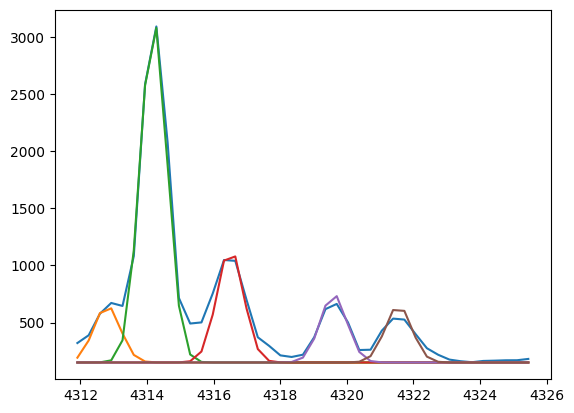

In [154]:
plt.plot(x_arc_hd, y_arc_hd)
plt.plot(x_arc_hd, 150 + gaussian(x_arc_hd,  500,  4312.8, 0, 0.4))
plt.plot(x_arc_hd, 150 + gaussian(x_arc_hd, 3000,  4314.2, 0, 0.4))
plt.plot(x_arc_hd, 150 + gaussian(x_arc_hd, 1000,  4316.5, 0, 0.4))
plt.plot(x_arc_hd, 150 + gaussian(x_arc_hd,  600,  4319.6, 0, 0.4))
plt.plot(x_arc_hd, 150 + gaussian(x_arc_hd,  500, 4321.55, 0, 0.4))

In [155]:
params_arc_hd = Parameters()
params_arc_hd.add('z', value=0.0, vary=False)
params_arc_hd.add('mu1', value= 4312.8, vary=False)
params_arc_hd.add('mu2', value= 4314.2, vary=False)
params_arc_hd.add('mu3', value= 4316.5, vary=False)
params_arc_hd.add('mu4', value= 4319.6, vary=False)
params_arc_hd.add('mu5', value=4321.55, vary=False)
params_arc_hd.add('arc1', value= 500, min=0.)
params_arc_hd.add('arc2', value=3000, min=0.)
params_arc_hd.add('arc3', value=1000, min=0.)
params_arc_hd.add('arc4', value= 600, min=0.)
params_arc_hd.add('arc5', value= 500, min=0.)
params_arc_hd.add('sigma', value=0.4, min=0.)
params_arc_hd.add('bkg', value=150, vary=False)

def residual_arc_hd(params_arc_hd, x, data, uncertainty):
    
    z = params_arc_hd['z']
    mu1 = params_arc_hd['mu1']
    mu2 = params_arc_hd['mu2']
    mu3 = params_arc_hd['mu3']
    mu4 = params_arc_hd['mu4']
    mu5 = params_arc_hd['mu5']
    flux1 = params_arc_hd['arc1']
    flux2 = params_arc_hd['arc2']
    flux3 = params_arc_hd['arc3']
    flux4 = params_arc_hd['arc4']
    flux5 = params_arc_hd['arc5']
    sigma = params_arc_hd['sigma']
    bkg = params_arc_hd['bkg']
    
    x = x_arc_hd
    model1 = gaussian(x, flux1, mu1, z, sigma)
    model2 = gaussian(x, flux2, mu2, z, sigma)
    model3 = gaussian(x, flux3, mu3, z, sigma)
    model4 = gaussian(x, flux4, mu4, z, sigma)
    model5 = gaussian(x, flux5, mu5, z, sigma)
    model = bkg + model1 + model2 + model3 + model4 + model5
    return (model - y_arc_hd) / 10

np.random.seed(23)
out_arc_hd = minimize(residual_arc_hd, params_arc_hd, args=(1, 1, 1),
                      method='emcee', burn=1500, steps=2500, thin=10)

100%|███████████████████████████████████████| 2500/2500 [01:24<00:00, 29.75it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 6 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [72.27349324 71.35569415 82.75629098 86.20275838 98.05388252 77.43452875]


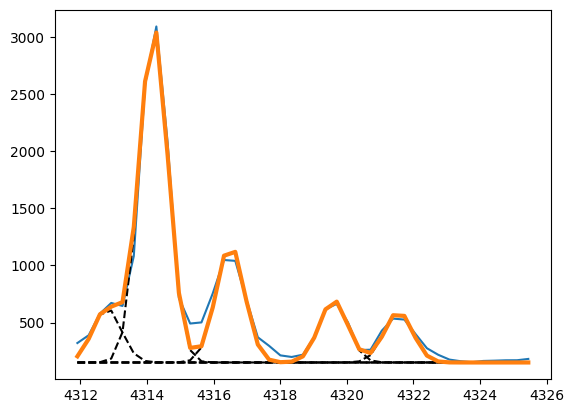

In [156]:
arc1_hd = out_arc_hd.flatchain.arc1.mean()
arc2_hd = out_arc_hd.flatchain.arc2.mean()
arc3_hd = out_arc_hd.flatchain.arc3.mean()
arc4_hd = out_arc_hd.flatchain.arc4.mean()
arc5_hd = out_arc_hd.flatchain.arc5.mean()
sigma_arc_hd = out_arc_hd.flatchain.sigma.mean()

plt.plot(x_arc_hd, y_arc_hd)

plt.plot(x_arc_hd, 150 + gaussian(x_arc_hd, arc1_hd,  4312.8, 0, sigma_arc_hd), ls='--', color='black')
plt.plot(x_arc_hd, 150 + gaussian(x_arc_hd, arc2_hd,  4314.2, 0, sigma_arc_hd), ls='--', color='black')
plt.plot(x_arc_hd, 150 + gaussian(x_arc_hd, arc3_hd,  4316.5, 0, sigma_arc_hd), ls='--', color='black')
plt.plot(x_arc_hd, 150 + gaussian(x_arc_hd, arc4_hd,  4319.6, 0, sigma_arc_hd), ls='--', color='black')
plt.plot(x_arc_hd, 150 + gaussian(x_arc_hd, arc5_hd, 4321.55, 0, sigma_arc_hd), ls='--', color='black')

plt.plot(x_arc_hd, 150 + gaussian(x_arc_hd, arc1_hd,  4312.8, 0, sigma_arc_hd) \
                       + gaussian(x_arc_hd, arc2_hd,  4314.2, 0, sigma_arc_hd) \
                       + gaussian(x_arc_hd, arc3_hd,  4316.5, 0, sigma_arc_hd) \
                       + gaussian(x_arc_hd, arc4_hd,  4319.6, 0, sigma_arc_hd) \
                       + gaussian(x_arc_hd, arc5_hd, 4321.55, 0, sigma_arc_hd), lw=3
)

# [OII]3726 + [OII]3729

### Arc lines

In [165]:
# Select a region of the arc spectra to have a few arc lines around the wavelength of the fitted lines
wlims_3729 = [wave_cat['[OII]3729']*(1 + z_BN[igal]) - 5, wave_cat['[OII]3729']*(1 + z_BN[igal]) + 5]
mask_arc_3729 = (wcal_blue[4].data['wave_soln'][0] >= wlims_3729[0]) & (wcal_blue[4].data['wave_soln'][0] < wlims_3729[1])

# Arc spectra around the fitted line
x_arc_3729 = wcal_blue[4].data['wave_soln'][0][mask_arc_3729]
y_arc_3729 = wcal_blue[25].data[:, 1][mask_arc_3729]

100%|███████████████████████████████████████| 2500/2500 [01:08<00:00, 36.64it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 3 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [75.17945201 20.76731829 62.81412507 61.6865987  23.75052843]


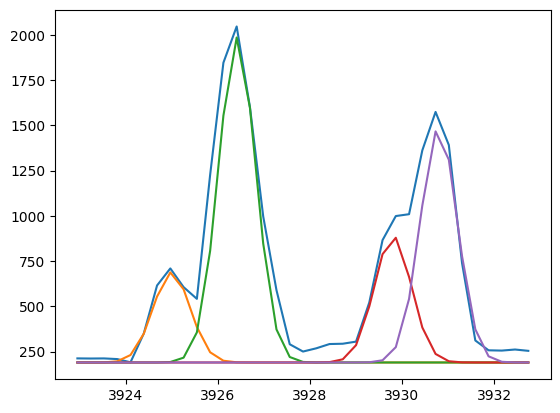

In [166]:
plt.plot(x_arc_3729, y_arc_3729)
plt.plot(x_arc_3729, 190 + gaussian(x_arc_3729, 500, 3925, 0, 0.4))
plt.plot(x_arc_3729, 190 + gaussian(x_arc_3729, 1800, 3926.42, 0, 0.4))
plt.plot(x_arc_3729, 190 + gaussian(x_arc_3729, 700, 3929.8, 0, 0.4))
plt.plot(x_arc_3729, 190 + gaussian(x_arc_3729, 1300, 3930.8, 0, 0.4))

params_arc_3729 = Parameters()
params_arc_3729.add('z', value=0.0, vary=False)
params_arc_3729.add('mu1', value=3925, vary=False)
params_arc_3729.add('mu2', value=3926.42, vary=False)
params_arc_3729.add('mu3', value=3929.8, vary=False)
params_arc_3729.add('mu4', value=3930.8, vary=False)
params_arc_3729.add('arc1', value=500, min=0.)
params_arc_3729.add('arc2', value=1800, min=0.)
params_arc_3729.add('arc3', value=7000, min=0.)
params_arc_3729.add('arc4', value=1300, min=0.)
params_arc_3729.add('sigma', value=0.4, min=0.)
params_arc_3729.add('bkg', value=190, vary=False)

def residual_arc_3729(params_arc_3729, x, data, uncertainty):
    
    z = params_arc_3729['z']
    mu1 = params_arc_3729['mu1']
    mu2 = params_arc_3729['mu2']
    mu3 = params_arc_3729['mu3']
    mu4 = params_arc_3729['mu4']
    flux1 = params_arc_3729['arc1']
    flux2 = params_arc_3729['arc2']
    flux3 = params_arc_3729['arc3']
    flux4 = params_arc_3729['arc4']
    sigma = params_arc_3729['sigma']
    bkg = params_arc_3729['bkg']
    
    x = x_arc_3729
    model1 = gaussian(x, flux1, mu1, z, sigma)
    model2 = gaussian(x, flux2, mu2, z, sigma)
    model3 = gaussian(x, flux3, mu3, z, sigma)
    model4 = gaussian(x, flux4, mu4, z, sigma)
    model = bkg + model1 + model2 + model3 + model4
    return (model - y_arc_3729) / 10

np.random.seed(23)
out_arc_3729 = minimize(residual_arc_3729, params_arc_3729, args=(1, 1, 1),
                      method='emcee', burn=1500, steps=2500, thin=10)

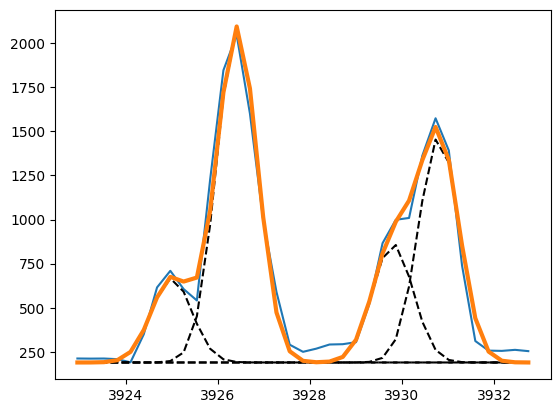

In [167]:
arc1_3729 = out_arc_3729.flatchain.arc1.mean()
arc2_3729 = out_arc_3729.flatchain.arc2.mean()
arc3_3729 = out_arc_3729.flatchain.arc3.mean()
arc4_3729 = out_arc_3729.flatchain.arc4.mean()
sigma_arc_3729 = out_arc_3729.flatchain.sigma.mean()

plt.plot(x_arc_3729, y_arc_3729)

plt.plot(x_arc_3729, 190 + gaussian(x_arc_3729, arc1_3729, 3925, 0, sigma_arc_3729), ls='--', color='black')
plt.plot(x_arc_3729, 190 + gaussian(x_arc_3729, arc2_3729, 3926.42, 0, sigma_arc_3729), ls='--', color='black')
plt.plot(x_arc_3729, 190 + gaussian(x_arc_3729, arc3_3729, 3929.8, 0, sigma_arc_3729), ls='--', color='black')
plt.plot(x_arc_3729, 190 + gaussian(x_arc_3729, arc4_3729, 3930.8, 0, sigma_arc_3729), ls='--', color='black')

plt.plot(x_arc_3729, 190 + gaussian(x_arc_3729, arc1_3729, 3925, 0, sigma_arc_3729) \
         + gaussian(x_arc_3729, arc2_3729, 3926.42, 0, sigma_arc_3729) \
         + gaussian(x_arc_3729, arc3_3729, 3929.8, 0, sigma_arc_3729) \
         + gaussian(x_arc_3729, arc4_3729, 3930.8, 0, sigma_arc_3729), lw=3
)

# [SIII]9532

### Arc lines

In [176]:
# Select a region of the arc spectra to have a few arc lines around the wavelength of the fitted lines
wlims_9532 = [wave_cat['[SIII]9532']*(1 + z_BN[igal]) - 5, wave_cat['[SIII]9532']*(1 + z_BN[igal]) + 30]
mask_arc_9532 = (wcal_red[20].data['wave_soln'][0] >= wlims_9532[0]) & (wcal_red[20].data['wave_soln'][0] < wlims_9532[1])

# Arc spectra around the fitted line
x_arc_9532 = wcal_red[20].data['wave_soln'][0][mask_arc_9532]
y_arc_9532 = wcal_red[23].data[:, 9][mask_arc_9532]

100%|███████████████████████████████████████| 2500/2500 [00:28<00:00, 86.62it/s]


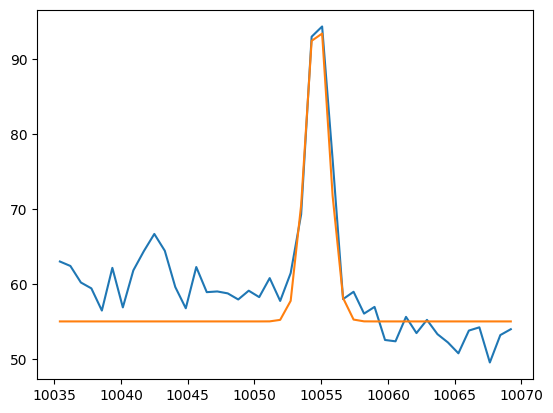

In [177]:
plt.plot(x_arc_9532, y_arc_9532)
plt.plot(x_arc_9532, 55 + gaussian(x_arc_9532, 90, 10054.7, 0, 0.85))

params_arc_9532 = Parameters()
params_arc_9532.add('z', value=0.0, vary=False)
params_arc_9532.add('mu', value=10054.7, vary=False)
params_arc_9532.add('arc', value=90, min=0.)
params_arc_9532.add('sigma', value=0.85, min=0.)
params_arc_9532.add('bkg', value=55, vary=True)

def residual_arc_9532(params_arc_9532, x, data, uncertainty):
    
    z = params_arc_9532['z']
    mu = params_arc_9532['mu']
    flux = params_arc_9532['arc']
    sigma = params_arc_9532['sigma']
    bkg = params_arc_9532['bkg']
    
    x = x_arc_9532
    model = gaussian(x, flux, mu, z, sigma)
    model = bkg + model
    return (model - y_arc_9532) / 10

np.random.seed(23)
out_arc_9532 = minimize(residual_arc_9532, params_arc_9532, args=(1, 1, 1),
                      method='emcee', burn=1500, steps=2500, thin=10)

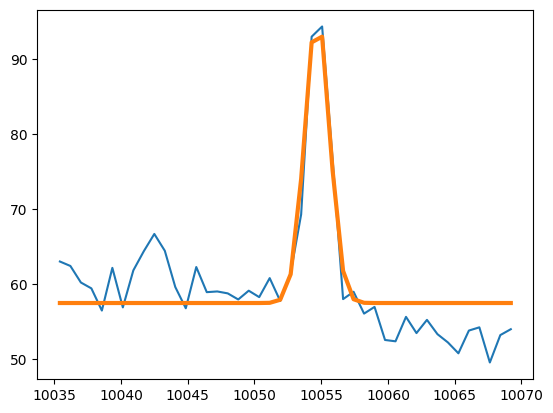

In [178]:
arc_9532 = out_arc_9532.params['arc'].value
sigma_arc_9532 = out_arc_9532.params['sigma'].value
bkg_9532 = out_arc_9532.params['bkg'].value

plt.plot(x_arc_9532, y_arc_9532)
plt.plot(x_arc_9532, bkg_9532 + gaussian(x_arc_9532, arc_9532, 10054.7, 0, sigma_arc_9532), lw=3)

# [SIII]9069

### Arc lines

In [187]:
# Select a region of the arc spectra to have a few arc lines around the wavelength of the fitted lines
wlims_9069 = [wave_cat['[SIII]9069']*(1 + z_BN[igal]) - 10, wave_cat['[SIII]9069']*(1 + z_BN[igal]) + 20]
mask_arc_9069 = (wcal_red[20].data['wave_soln'][0] >= wlims_9069[0]) & (wcal_red[20].data['wave_soln'][0] < wlims_9069[1])

# Arc spectra around the fitted line
x_arc_9069 = wcal_red[20].data['wave_soln'][0][mask_arc_9069]
y_arc_9069 = wcal_red[23].data[:, 9][mask_arc_9069]

100%|███████████████████████████████████████| 2500/2500 [00:27<00:00, 90.02it/s]


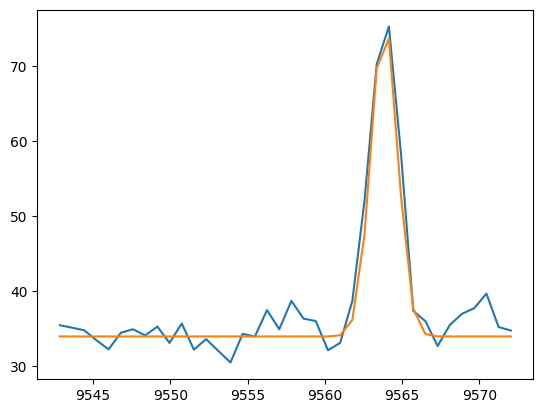

In [188]:
plt.plot(x_arc_9069, y_arc_9069)
plt.plot(x_arc_9069, 34 + gaussian(x_arc_9069, 90, 9563.85, 0, 0.85))

params_arc_9069 = Parameters()
params_arc_9069.add('z', value=0.0, vary=False)
params_arc_9069.add('mu', value=9563.85, vary=False)
params_arc_9069.add('arc', value=90, min=0.)
params_arc_9069.add('sigma', value=0.85, min=0.)
params_arc_9069.add('bkg', value=34, vary=False)

def residual_arc_9069(params_arc_9069, x, data, uncertainty):
    
    z = params_arc_9069['z']
    mu = params_arc_9069['mu']
    flux = params_arc_9069['arc']
    sigma = params_arc_9069['sigma']
    bkg = params_arc_9069['bkg']
    
    x = x_arc_9069
    model = bkg + gaussian(x, flux, mu, z, sigma)
    return (model - y_arc_9069) / 10

np.random.seed(23)
out_arc_9069 = minimize(residual_arc_9069, params_arc_9069, args=(1, 1, 1),
                      method='emcee', burn=1500, steps=2500, thin=10)

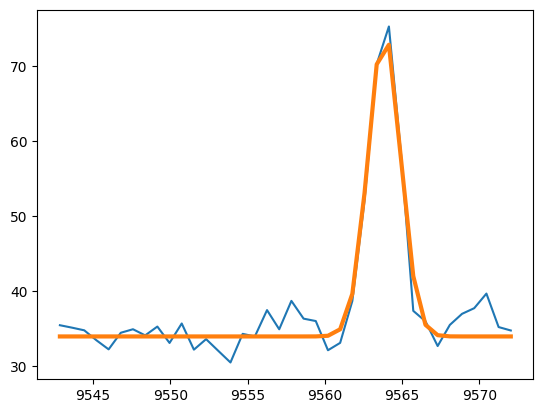

In [189]:
arc_9069 = out_arc_9069.params['arc'].value
sigma_arc_9069 = out_arc_9069.params['sigma'].value

plt.plot(x_arc_9069, y_arc_9069)
plt.plot(x_arc_9069, 34 + gaussian(x_arc_9069, arc_9069, 9563.85, 0, sigma_arc_9069), lw=3)

# [OI]6300 + [SIII]6312

### Arc lines

In [198]:
# Select a region of the arc spectra to have a few arc lines around the wavelength of the fitted lines
wlims_6312 = [wave_cat['[SIII]6312']*(1 + z_BN[igal]) - 10, wave_cat['[SIII]6312']*(1 + z_BN[igal]) + 10]
mask_arc_6312 = (wcal_red[14].data['wave_soln'][0] >= wlims_6312[0]) & (wcal_red[14].data['wave_soln'][0] < wlims_6312[1])

# Arc spectra around the fitted line
x_arc_6312 = wcal_red[14].data['wave_soln'][0][mask_arc_6312]
y_arc_6312 = wcal_red[23].data[:, 6][mask_arc_6312]

100%|███████████████████████████████████████| 2500/2500 [00:34<00:00, 72.26it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 3 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [69.96438323 56.82614945 43.45037814 35.74578022 64.10734893]


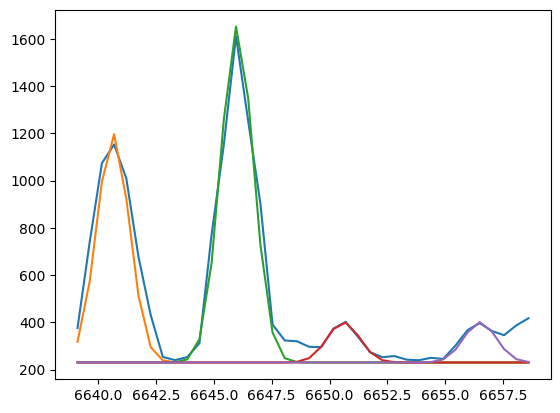

In [199]:
plt.plot(x_arc_6312, y_arc_6312)
plt.plot(x_arc_6312, 230 + gaussian(x_arc_6312, 1700, 6640.65, 0, 0.7))
plt.plot(x_arc_6312, 230 + gaussian(x_arc_6312, 2500, 6646, 0, 0.7))
plt.plot(x_arc_6312, 230 + gaussian(x_arc_6312, 300, 6650.6, 0, 0.7))
plt.plot(x_arc_6312, 230 + gaussian(x_arc_6312, 300, 6656.5, 0, 0.7))

params_arc_6312 = Parameters()
params_arc_6312.add('z', value=0.0, vary=False)
params_arc_6312.add('mu1', value=6640.65, vary=False)
params_arc_6312.add('mu2', value=6646, vary=False)
params_arc_6312.add('mu3', value=6650.6, vary=False)
params_arc_6312.add('mu4', value=6656.5, vary=False)
params_arc_6312.add('arc1', value=1700, min=0.)
params_arc_6312.add('arc2', value=2500, min=0.)
params_arc_6312.add('arc3', value=300, min=0.)
params_arc_6312.add('arc4', value=300, min=0.)
params_arc_6312.add('sigma', value=0.7, min=0.)
params_arc_6312.add('bkg', value=230, vary=False)

def residual_arc_6312(params_arc_6312, x, data, uncertainty):
    
    z = params_arc_6312['z']
    mu1 = params_arc_6312['mu1']
    mu2 = params_arc_6312['mu2']
    mu3 = params_arc_6312['mu3']
    mu4 = params_arc_6312['mu4']
    flux1 = params_arc_6312['arc1']
    flux2 = params_arc_6312['arc2']
    flux3 = params_arc_6312['arc3']
    flux4 = params_arc_6312['arc4']
    sigma = params_arc_6312['sigma']
    bkg = params_arc_6312['bkg']
    
    x = x_arc_6312
    model1 = gaussian(x, flux1, mu1, z, sigma)
    model2 = gaussian(x, flux2, mu2, z, sigma)
    model3 = gaussian(x, flux3, mu3, z, sigma)
    model4 = gaussian(x, flux4, mu4, z, sigma)
    model = bkg + model1 + model2 + model3 + model4
    return (model - y_arc_6312) / 10

np.random.seed(23)
out_arc_6312 = minimize(residual_arc_6312, params_arc_6312, args=(1, 1, 1),
                      method='emcee', burn=1500, steps=2500, thin=10)

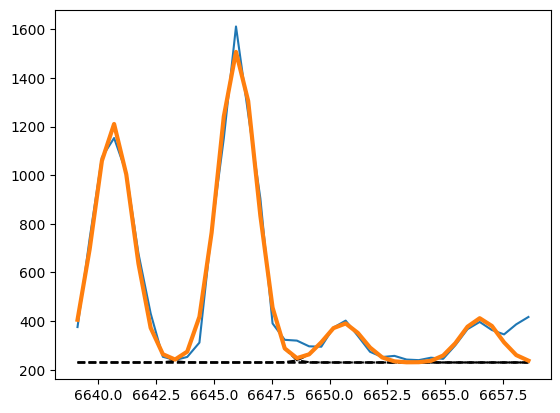

In [200]:
arc1_6312 = out_arc_6312.flatchain.arc1.mean()
arc2_6312 = out_arc_6312.flatchain.arc2.mean()
arc3_6312 = out_arc_6312.flatchain.arc3.mean()
arc4_6312 = out_arc_6312.flatchain.arc4.mean()
sigma_arc_6312 = out_arc_6312.flatchain.sigma.mean()

plt.plot(x_arc_6312, y_arc_6312)

plt.plot(x_arc_6312, 230 + gaussian(x_arc_6312, arc1_6312, 6640.65, 0, sigma_arc_6312), ls='--', color='black')
plt.plot(x_arc_6312, 230 + gaussian(x_arc_6312, arc2_6312, 6646, 0, sigma_arc_6312), ls='--', color='black')
plt.plot(x_arc_6312, 230 + gaussian(x_arc_6312, arc3_6312, 6650.6, 0, sigma_arc_6312), ls='--', color='black')
plt.plot(x_arc_6312, 230 + gaussian(x_arc_6312, arc4_6312, 6656.5, 0, sigma_arc_6312), ls='--', color='black')

plt.plot(x_arc_6312, 230 + gaussian(x_arc_6312, arc1_6312, 6640.65, 0, sigma_arc_6312) \
         + gaussian(x_arc_6312, arc2_6312, 6646, 0, sigma_arc_6312) \
         + gaussian(x_arc_6312, arc3_6312, 6650.6, 0, sigma_arc_6312) \
         + gaussian(x_arc_6312, arc4_6312, 6656.5, 0, sigma_arc_6312), lw=3
)

# [OIII]5007 + HeI 5015

### Arc lines

In [209]:
# Select a region of the arc spectra to have a few arc lines around the wavelength of the fitted lines
wlims_5007 = [wave_cat['[OIII]5007']*(1 + z_BN[igal]) - 10, wave_cat['[OIII]5007']*(1 + z_BN[igal]) + 10]
mask_arc_5007 = (wcal_blue[12].data['wave_soln'][0] >= wlims_5007[0]) & (wcal_blue[12].data['wave_soln'][0] < wlims_5007[1])

# Arc spectra around the fitted line
x_arc_5007 = wcal_blue[12].data['wave_soln'][0][mask_arc_5007]
y_arc_5007 = wcal_blue[25].data[:, 5][mask_arc_5007]

100%|███████████████████████████████████████| 2500/2500 [00:28<00:00, 88.37it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 1 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [44.91903903 45.01040465 47.19636218 46.7885072  52.08901673]


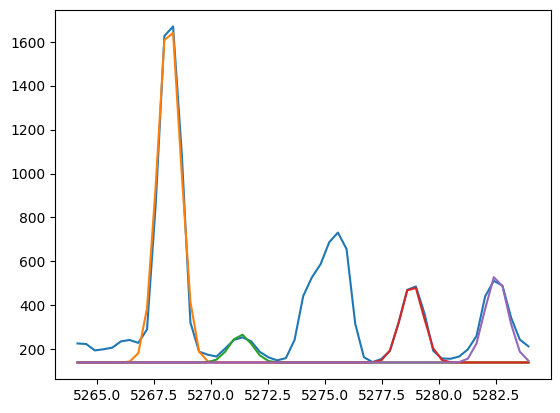

In [210]:
plt.plot(x_arc_5007, y_arc_5007)
plt.plot(x_arc_5007, 140 + gaussian(x_arc_5007, 2000, 5268.15, 0, 0.5))
plt.plot(x_arc_5007, 140 + gaussian(x_arc_5007, 160, 5271.3, 0, 0.5))
plt.plot(x_arc_5007, 140 + gaussian(x_arc_5007, 450, 5278.8, 0, 0.5))
plt.plot(x_arc_5007, 140 + gaussian(x_arc_5007, 500, 5282.5, 0, 0.5))

params_arc_5007 = Parameters()
params_arc_5007.add('z', value=0.0, vary=False)
params_arc_5007.add('mu1', value=5268.15, vary=False)
params_arc_5007.add('mu2', value=5271.3, vary=False)
params_arc_5007.add('mu3', value=5278.8, vary=False)
params_arc_5007.add('mu4', value=5282.5, vary=False)
params_arc_5007.add('arc1', value=2000, min=0.)
params_arc_5007.add('arc2', value=160, min=0.)
params_arc_5007.add('arc3', value=450, min=0.)
params_arc_5007.add('arc4', value=500, min=0.)
params_arc_5007.add('sigma', value=0.5, min=0.)
params_arc_5007.add('bkg', value=140, vary=False)

def residual_arc_5007(params_arc_5007, x, data, uncertainty):
    
    z = params_arc_5007['z']
    mu1 = params_arc_5007['mu1']
    mu2 = params_arc_5007['mu2']
    mu3 = params_arc_5007['mu3']
    mu4 = params_arc_5007['mu4']
    flux1 = params_arc_5007['arc1']
    flux2 = params_arc_5007['arc2']
    flux3 = params_arc_5007['arc3']
    flux4 = params_arc_5007['arc4']
    sigma = params_arc_5007['sigma']
    bkg = params_arc_5007['bkg']
    
    x = x_arc_5007
    model1 = gaussian(x, flux1, mu1, z, sigma)
    model2 = gaussian(x, flux2, mu2, z, sigma)
    model3 = gaussian(x, flux3, mu3, z, sigma)
    model4 = gaussian(x, flux4, mu4, z, sigma)
    model = bkg + model1 + model2 + model3 + model4
    return (model - y_arc_5007) / 10

np.random.seed(23)
out_arc_5007 = minimize(residual_arc_5007, params_arc_5007, args=(1, 1, 1),
                      method='emcee', burn=1500, steps=2500, thin=10)

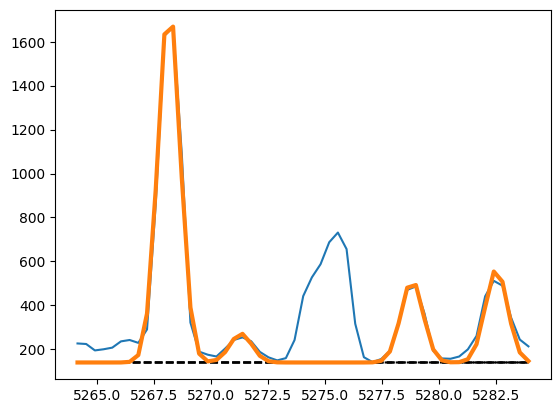

In [211]:
arc1_5007 = out_arc_5007.flatchain.arc1.mean()
arc2_5007 = out_arc_5007.flatchain.arc2.mean()
arc3_5007 = out_arc_5007.flatchain.arc3.mean()
arc4_5007 = out_arc_5007.flatchain.arc4.mean()
sigma_arc_5007 = out_arc_5007.flatchain.sigma.mean()

plt.plot(x_arc_5007, y_arc_5007)

plt.plot(x_arc_5007, 140 + gaussian(x_arc_5007, arc1_5007, 5268.15, 0, sigma_arc_5007), ls='--', color='black')
plt.plot(x_arc_5007, 140 + gaussian(x_arc_5007, arc2_5007, 5271.3, 0, sigma_arc_5007), ls='--', color='black')
plt.plot(x_arc_5007, 140 + gaussian(x_arc_5007, arc3_5007, 5278.8, 0, sigma_arc_5007), ls='--', color='black')
plt.plot(x_arc_5007, 140 + gaussian(x_arc_5007, arc4_5007, 5282.5, 0, sigma_arc_5007), ls='--', color='black')

plt.plot(x_arc_5007, 140 + gaussian(x_arc_5007, arc1_5007, 5268.15, 0, sigma_arc_5007) \
         + gaussian(x_arc_5007, arc2_5007, 5271.3, 0, sigma_arc_5007) \
         + gaussian(x_arc_5007, arc3_5007, 5278.8, 0, sigma_arc_5007) \
         + gaussian(x_arc_5007, arc4_5007, 5282.5, 0, sigma_arc_5007), lw=3
)

# [OIII]4363

### Arc lines

In [220]:
# Select a region of the arc spectra to have a few arc lines around the wavelength of the fitted lines
wlims_4363 = [wave_cat['[OIII]4363']*(1 + z_BN[igal]) - 10, wave_cat['[OIII]4363']*(1 + z_BN[igal]) + 8]
mask_arc_4363 = (wcal_blue[8].data['wave_soln'][0] >= wlims_4363[0]) & (wcal_blue[8].data['wave_soln'][0] < wlims_4363[1])

# Arc spectra around the fitted line
x_arc_4363 = wcal_blue[8].data['wave_soln'][0][mask_arc_4363]
y_arc_4363 = wcal_blue[25].data[:, 3][mask_arc_4363]

100%|███████████████████████████████████████| 2500/2500 [00:29<00:00, 85.91it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 6 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [52.53820306 75.18808864 61.99822262 81.93688931 60.53905513 75.65590289]


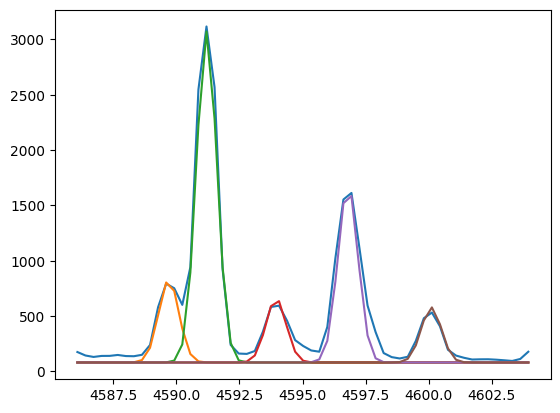

In [221]:
plt.plot(x_arc_4363, y_arc_4363)
plt.plot(x_arc_4363, 80 + gaussian(x_arc_4363, 750, 4589.7, 0, 0.4))
plt.plot(x_arc_4363, 80 + gaussian(x_arc_4363, 3000, 4591.2, 0, 0.4))
plt.plot(x_arc_4363, 80 + gaussian(x_arc_4363, 580, 4593.95, 0, 0.4))
plt.plot(x_arc_4363, 80 + gaussian(x_arc_4363, 1600, 4596.8, 0, 0.4))
plt.plot(x_arc_4363, 80 + gaussian(x_arc_4363, 500, 4600.1, 0, 0.4))

params_arc_4363 = Parameters()
params_arc_4363.add('z', value=0.0, vary=False)
params_arc_4363.add('mu1', value=4589.7, vary=False)
params_arc_4363.add('mu2', value=4591.2, vary=False)
params_arc_4363.add('mu3', value=4593.95, vary=False)
params_arc_4363.add('mu4', value=4596.8, vary=False)
params_arc_4363.add('mu5', value=4600.1, vary=False)
params_arc_4363.add('arc1', value=750, min=0.)
params_arc_4363.add('arc2', value=3000, min=0.)
params_arc_4363.add('arc3', value=580, min=0.)
params_arc_4363.add('arc4', value=1600, min=0.)
params_arc_4363.add('arc5', value=500, min=0.)
params_arc_4363.add('sigma', value=0.4, min=0.)
params_arc_4363.add('bkg', value=80, vary=False)

def residual_arc_4363(params_arc_4363, x, data, uncertainty):
    
    z = params_arc_4363['z']
    mu1 = params_arc_4363['mu1']
    mu2 = params_arc_4363['mu2']
    mu3 = params_arc_4363['mu3']
    mu4 = params_arc_4363['mu4']
    mu5 = params_arc_4363['mu5']
    flux1 = params_arc_4363['arc1']
    flux2 = params_arc_4363['arc2']
    flux3 = params_arc_4363['arc3']
    flux4 = params_arc_4363['arc4']
    flux5 = params_arc_4363['arc5']
    sigma = params_arc_4363['sigma']
    bkg = params_arc_4363['bkg']
    
    x = x_arc_4363
    model1 = gaussian(x, flux1, mu1, z, sigma)
    model2 = gaussian(x, flux2, mu2, z, sigma)
    model3 = gaussian(x, flux3, mu3, z, sigma)
    model4 = gaussian(x, flux4, mu4, z, sigma)
    model5 = gaussian(x, flux5, mu5, z, sigma)
    model = bkg + model1 + model2 + model3 + model4 + model5
    return (model - y_arc_4363) / 10

np.random.seed(23)
out_arc_4363 = minimize(residual_arc_4363, params_arc_4363, args=(1, 1, 1),
                      method='emcee', burn=1500, steps=2500, thin=10)

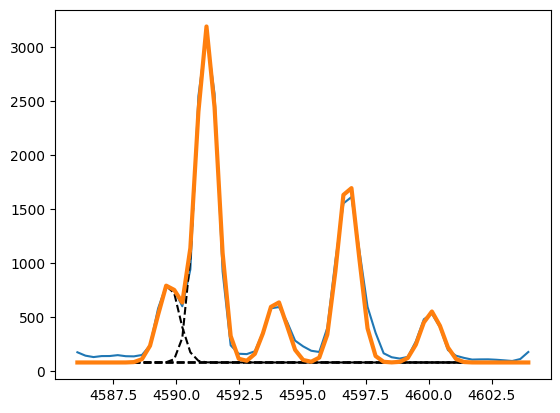

In [222]:
arc1_4363 = out_arc_4363.flatchain.arc1.mean()
arc2_4363 = out_arc_4363.flatchain.arc2.mean()
arc3_4363 = out_arc_4363.flatchain.arc3.mean()
arc4_4363 = out_arc_4363.flatchain.arc4.mean()
arc5_4363 = out_arc_4363.flatchain.arc5.mean()
sigma_arc_4363 = out_arc_4363.flatchain.sigma.mean()

plt.plot(x_arc_4363, y_arc_4363)

plt.plot(x_arc_4363, 80 + gaussian(x_arc_4363, arc1_4363, 4589.7, 0, sigma_arc_4363), ls='--', color='black')
plt.plot(x_arc_4363, 80 + gaussian(x_arc_4363, arc2_4363, 4591.2, 0, sigma_arc_4363), ls='--', color='black')
plt.plot(x_arc_4363, 80 + gaussian(x_arc_4363, arc3_4363, 4593.95, 0, sigma_arc_4363), ls='--', color='black')
plt.plot(x_arc_4363, 80 + gaussian(x_arc_4363, arc4_4363, 4596.8, 0, sigma_arc_4363), ls='--', color='black')
plt.plot(x_arc_4363, 80 + gaussian(x_arc_4363, arc5_4363, 4600.1, 0, sigma_arc_4363), ls='--', color='black')

plt.plot(x_arc_4363, 80 + gaussian(x_arc_4363, arc1_4363, 4589.7, 0, sigma_arc_4363) \
         + gaussian(x_arc_4363, arc2_4363, 4591.2, 0, sigma_arc_4363) \
         + gaussian(x_arc_4363, arc3_4363, 4593.95, 0, sigma_arc_4363) \
         + gaussian(x_arc_4363, arc4_4363, 4596.8, 0, sigma_arc_4363) \
         + gaussian(x_arc_4363, arc5_4363, 4600.1, 0, sigma_arc_4363), lw=3
)

# Saving arc data

In [231]:
sigma_arc = np.array([sigma_arc_3729,
                      sigma_arc_hd,
                      sigma_arc_hg,
                      sigma_arc_4363,
                      sigma_arc_4471,
                      sigma_arc_4685,
                      sigma_arc_hb,
                      sigma_arc_4959,
                      sigma_arc_5007,
                      sigma_arc_5875,
                      sigma_arc_6312,
                      sigma_arc_ha,
                      sigma_arc_6678,
                      sigma_arc_6730,
                      sigma_arc_7065,
                      sigma_arc_7330,
                      sigma_arc_9069,
                      sigma_arc_9532])

x_arc = np.array([np.median(x_arc_3729),
                  np.median(x_arc_hd),
                  np.median(x_arc_hg),
                  np.median(x_arc_4363),
                  np.median(x_arc_4471),
                  np.median(x_arc_4685),
                  np.median(x_arc_hb),
                  np.median(x_arc_4959),
                  np.median(x_arc_5007),
                  np.median(x_arc_5875),
                  np.median(x_arc_6312),
                  np.median(x_arc_ha),
                  np.median(x_arc_6678),
                  np.median(x_arc_6730),
                  np.median(x_arc_7065),
                  np.median(x_arc_7330),
                  np.median(x_arc_9069),
                  np.median(x_arc_9532)])

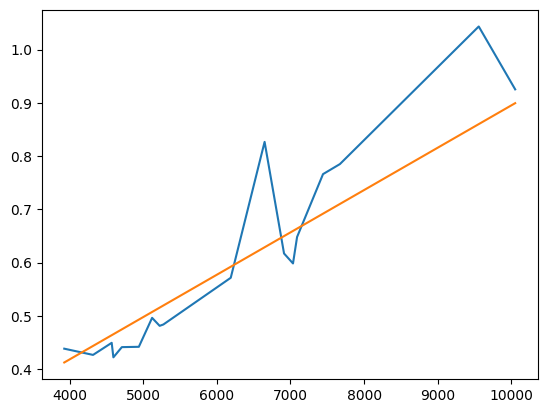

In [232]:
plt.plot(x_arc, sigma_arc)
plt.plot(x_arc, (((sigma_arc[-1] - sigma_arc[0])/(x_arc[-1] - x_arc[0])) * x_arc) + 0.1)

In [233]:
params_sigma_arc = Parameters()
params_sigma_arc.add('m', value=8.850519511761363e-05)
params_sigma_arc.add('n', value=0.1)

def residual_sigma_arc(params_sigma_arc, x, data, uncertainty):
    
    m = params_sigma_arc['m']
    n = params_sigma_arc['n']
    
    x = x_arc
    model = (m * x_arc) + n
    return (model - sigma_arc) / 0.05

np.random.seed(136)
out_sigma_arc = minimize(residual_sigma_arc, params_sigma_arc, args=(1, 1, 1),
                      method='emcee', burn=1500, steps=2500, thin=10)

100%|██████████████████████████████████████| 2500/2500 [00:10<00:00, 227.74it/s]


In [234]:
lmfit.report_fit(out_sigma_arc.params)

[[Variables]]
    m:  1.0181e-04 +/- 6.9595e-06 (6.84%) (init = 8.85052e-05)
    n: -0.02634920 +/- 0.04450977 (168.92%) (init = 0.1)
[[Correlations]] (unreported correlations are < 0.100)
    C(m, n) = -0.9642


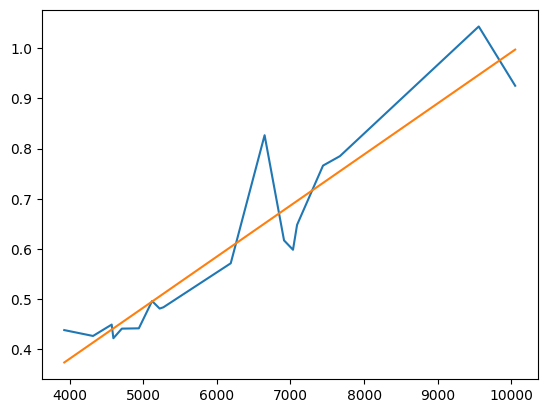

In [235]:
m = out_sigma_arc.flatchain.m.mean()
n = out_sigma_arc.flatchain.n.mean()

plt.plot(x_arc, sigma_arc)
plt.plot(x_arc, (m * x_arc) + n)